In [1]:
print("hello world")

hello world


# test Env

In [2]:
import sys
import platform
import torch


print("HASTIKA ENVIRONMENT CHECK")



print(f"Python version : {platform.python_version()}")
print(f"Python path    : {sys.executable}")

print(f"\nPyTorch version: {torch.__version__}")

print(f"CUDA available : {torch.cuda.is_available()}")
print(f"CUDA version   : {torch.version.cuda}")

if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"GPU count      : {torch.cuda.device_count()}")
else:
    print("GPU            : Not available")



HASTIKA ENVIRONMENT CHECK
Python version : 3.11.9
Python path    : S:\4.2\bangla\Hastika-ICON2026\.venv\Scripts\python.exe

PyTorch version: 2.11.0+cu128
CUDA available : True
CUDA version   : 12.8
GPU            : NVIDIA GeForce RTX 3050 Laptop GPU
GPU count      : 1


# load datasets

In [3]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data")

# Task A: Binary classification
binary_train = pd.read_csv(DATA_DIR / "binary_train.csv")
binary_val = pd.read_csv(DATA_DIR / "binary_validation_inputs.csv")

# Task B: Multiclass classification
multiclass_train = pd.read_csv(DATA_DIR / "multiclass_train.csv")
multiclass_val = pd.read_csv(DATA_DIR / "multiclass_validation_inputs.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [4]:
# check the data sets

print("Binary Training Data      :", binary_train.shape)
print("Binary Validation Data    :", binary_val.shape)
print("Multiclass Training Data  :", multiclass_train.shape)
print("Multiclass Validation Data:", multiclass_val.shape)

Binary Training Data      : (6446, 3)
Binary Validation Data    : (806, 2)
Multiclass Training Data  : (3159, 3)
Multiclass Validation Data: (395, 2)


In [5]:
print("TASK A — Binary Training")
display(binary_train.head())

print("\nTASK B — Multiclass Training")
display(multiclass_train.head())

TASK A — Binary Training


,id,Comment,Label
0,7417,Mir.Amarprasad nimage dhairya iddalli Sri raji...,Non-Hate
1,1549,"amar sir , à²à³à²¹à³à²²à²¿ Bad performance,...",Non-Hate
2,5944,yarige bekittu inthadella avar hatra en ide bo...,Hate
3,7700,Ara hu cha evanu aa taliban mmaat keli illi ba...,Hate
4,1293,Enu boss bartha bartha hero kale kami agthide,Hate



TASK B — Multiclass Training


,id,Comment,Hate Category
0,958,Bajetigu odalikke takarau maduvashtu vyavadana...,Political
1,4693,Unnata shikshana sachivanaagi Tippu bagge apap...,Political
2,2194,Ivlu papa avr ammage respect kodalla inn mugit...,Gender
3,3073,Nin english illi yeno ankonde adre big boss al...,Gender
4,1801,intha ugrarannu support maduva namma kelavobba...,Violence


In [6]:
print("Binary train columns     :", binary_train.columns.tolist())
print("Binary validation columns:", binary_val.columns.tolist())
print("Multiclass train columns :", multiclass_train.columns.tolist())
print("Multiclass validation    :", multiclass_val.columns.tolist())

Binary train columns     : ['id', 'Comment', 'Label']
Binary validation columns: ['id', 'Comment']
Multiclass train columns : ['id', 'Comment', 'Hate Category']
Multiclass validation    : ['id', 'Comment']


# check text encoding

In [13]:
import pandas as pd
import re

def check_text_encoding(df, text_col="Comment", sample_size=10):
    texts = df[text_col].dropna().astype(str)

    # Common signs of UTF-8 decoded incorrectly as Latin-1/Windows-1252
    mojibake_pattern = re.compile(r"(à[^\s]{0,3}|â[^\s]{0,3}|ð[^\s]{0,3}|Ã[^\s]{0,3})")

    mojibake_count = 0
    replacement_count = 0
    kannada_count = 0
    non_ascii_count = 0

    for text in texts:
        if mojibake_pattern.search(text):
            mojibake_count += 1

        if "\ufffd" in text:
            replacement_count += 1

        if any("\u0c80" <= c <= "\u0cff" for c in text):
            kannada_count += 1

        if any(ord(c) > 127 for c in text):
            non_ascii_count += 1

    print("=" * 60)
    print("TEXT ENCODING CHECK")
    print("=" * 60)

    print(f"Total comments checked : {len(texts):,}")
    print(f"Non-ASCII comments     : {non_ascii_count:,}")
    print(f"Kannada comments       : {kannada_count:,}")
    print(f"Mojibake detected      : {mojibake_count:,}")
    print(f"Replacement chars (?)  : {replacement_count:,}")

    print("\n--- Sample comments ---")

    for i, text in enumerate(texts.head(sample_size)):
        print(f"\n[{i}] {text}")

    print("\n--- Encoding diagnosis ---")

    if replacement_count > 0:
        print("Replacement characters (?) detected.")
        print("Some characters may already be irreversibly corrupted.")

    elif mojibake_count > 0:
        print("POSSIBLE ENCODING PROBLEM DETECTED.")
        print("Patterns such as 'à²', 'à³', 'Ã', 'â' or 'ð' were found.")
        print("This commonly indicates UTF-8 text decoded using the wrong encoding.")

    elif kannada_count > 0:
        print("Kannada Unicode characters detected correctly.")
        print("No obvious mojibake pattern detected.")

    else:
        print("No Kannada Unicode characters detected in the sample.")
        print("The dataset may contain mostly Romanized Kannada/English.")

    print("=" * 60)


# Task A
print("TASK A")
check_text_encoding(binary_train)

# Task B
print("\nTASK B")
check_text_encoding(multiclass_train)

TASK A
TEXT ENCODING CHECK
Total comments checked : 6,446
Non-ASCII comments     : 1,016
Kannada comments       : 0
Mojibake detected      : 1,003
Replacement chars (?)  : 0

--- Sample comments ---

[0] Mir.Amarprasad nimage dhairya iddalli Sri rajiv dixit ravara kurithagi ondu video madi

[1] amar sir , à²à³à²¹à³à²²à²¿ Bad performance, eshto world best players à²¨ Best performance.<br> &quot; Level of KING KOHLI ðª

[2] yarige bekittu inthadella avar hatra en ide bomb irbek ashte

[3] Ara hu cha evanu aa taliban mmaat keli illi banidane

[4] Enu boss bartha bartha hero kale kami agthide

[5] Chaple thagond hodire e sulle ge

[6] Ninu antavle bidu. Tayianthe maglu. Honnayakanahalli li ninu dodda dagar antha modle elargu gothu

[7] Le dummi anchor batte bichi torsodu sadane na..

[8] Dagar mundevu

[9] Avana name haenu antha ghotthaglilla avani sulae maga avara Amma nijavagalu ibbanae appa Amma Hilla aa qurel man  beverci alkat thoo avana mukakkae yava partiyavaru  avanannu gallig

In [9]:
def fix_mojibake(text):
    try:
        return text.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return text


# Test on a few affected comments
for i in [1, 3, 7]:
    original = binary_train.loc[i, "Comment"]
    fixed = fix_mojibake(original)

    print("=" * 70)
    print("ORIGINAL:")
    print(original)
    print("\nFIXED:")
    print(fixed)

ORIGINAL:
amar sir , à²à³à²¹à³à²²à²¿ Bad performance, eshto world best players à²¨ Best performance.<br> &quot; Level of KING KOHLI ðª

FIXED:
amar sir , ಕೊಹ್ಲಿ Bad performance, eshto world best players ನ Best performance.<br> &quot; Level of KING KOHLI 💪
ORIGINAL:
Ara hu cha evanu aa taliban mmaat keli illi banidane

FIXED:
Ara hu cha evanu aa taliban mmaat keli illi banidane
ORIGINAL:
Le dummi anchor batte bichi torsodu sadane na..

FIXED:
Le dummi anchor batte bichi torsodu sadane na..


In [14]:
def fix_mojibake(text):
    try:
        return text.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return text


# Create corrected text columns
binary_train["Comment_clean"] = binary_train["Comment"].apply(fix_mojibake)
binary_val["Comment_clean"] = binary_val["Comment"].apply(fix_mojibake)

multiclass_train["Comment_clean"] = multiclass_train["Comment"].apply(fix_mojibake)
multiclass_val["Comment_clean"] = multiclass_val["Comment"].apply(fix_mojibake)

print("Encoding correction completed.")

Encoding correction completed.


In [15]:
def encoding_summary(df, name):
    original_mojibake = df["Comment"].astype(str).str.contains(
        r"à|â|ð|Ã", regex=True
    ).sum()

    cleaned_kannada = df["Comment_clean"].astype(str).apply(
        lambda x: any("\u0c80" <= c <= "\u0cff" for c in x)
    ).sum()

    print("=" * 60)
    print(name)
    print("=" * 60)
    print(f"Rows                    : {len(df):,}")
    print(f"Original mojibake       : {original_mojibake:,}")
    print(f"Cleaned Kannada text    : {cleaned_kannada:,}")


encoding_summary(binary_train, "Binary Training")
encoding_summary(binary_val, "Binary Validation")
encoding_summary(multiclass_train, "Multiclass Training")
encoding_summary(multiclass_val, "Multiclass Validation")

Binary Training
Rows                    : 6,446
Original mojibake       : 1,003
Cleaned Kannada text    : 45
Binary Validation
Rows                    : 806
Original mojibake       : 138
Cleaned Kannada text    : 4
Multiclass Training
Rows                    : 3,159
Original mojibake       : 213
Cleaned Kannada text    : 4
Multiclass Validation
Rows                    : 395
Original mojibake       : 22
Cleaned Kannada text    : 2


In [16]:
print("\nSample corrected comments:\n")

for i in range(10):
    if binary_train.loc[i, "Comment"] != binary_train.loc[i, "Comment_clean"]:
        print("ORIGINAL:")
        print(binary_train.loc[i, "Comment"])
        print("\nCORRECTED:")
        print(binary_train.loc[i, "Comment_clean"])
        print("\n" + "-" * 70)


Sample corrected comments:

ORIGINAL:
amar sir , à²à³à²¹à³à²²à²¿ Bad performance, eshto world best players à²¨ Best performance.<br> &quot; Level of KING KOHLI ðª

CORRECTED:
amar sir , ಕೊಹ್ಲಿ Bad performance, eshto world best players ನ Best performance.<br> &quot; Level of KING KOHLI 💪

----------------------------------------------------------------------


# data inspection

In [17]:
# Dataset quality inspection

datasets = {
    "Binary Train": binary_train,
    "Binary Validation": binary_val,
    "Multiclass Train": multiclass_train,
    "Multiclass Validation": multiclass_val
}

for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print("=" * 70)

    print("Shape:", df.shape)

    print("\nMissing values:")
    print(df.isnull().sum())

    print("\nDuplicate rows:", df.duplicated().sum())
    print("Duplicate comments:", df["Comment_clean"].duplicated().sum())

    if "Label" in df.columns:
        print("\nLabels:")
        print(df["Label"].value_counts())

    if "Hate Category" in df.columns:
        print("\nHate Categories:")
        print(df["Hate Category"].value_counts())

    print()

Binary Train
Shape: (6446, 4)

Missing values:
id               0
Comment          0
Label            0
Comment_clean    0
dtype: int64

Duplicate rows: 0
Duplicate comments: 37

Labels:
Label
Non-Hate    3286
Hate        3160
Name: count, dtype: int64

Binary Validation
Shape: (806, 3)

Missing values:
id               0
Comment          0
Comment_clean    0
dtype: int64

Duplicate rows: 0
Duplicate comments: 0

Multiclass Train
Shape: (3159, 4)

Missing values:
id               0
Comment          0
Hate Category    0
Comment_clean    0
dtype: int64

Duplicate rows: 0
Duplicate comments: 13

Hate Categories:
Hate Category
Gender           1362
Political         559
Others            449
Religion          382
Violence          221
Geo-political     186
Name: count, dtype: int64

Multiclass Validation
Shape: (395, 3)

Missing values:
id               0
Comment          0
Comment_clean    0
dtype: int64

Duplicate rows: 0
Duplicate comments: 0



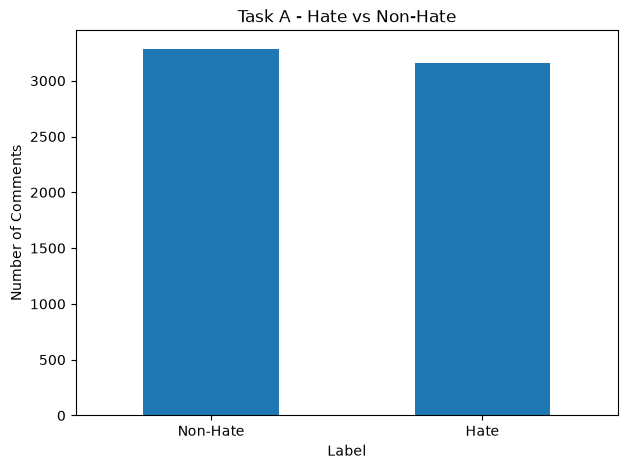

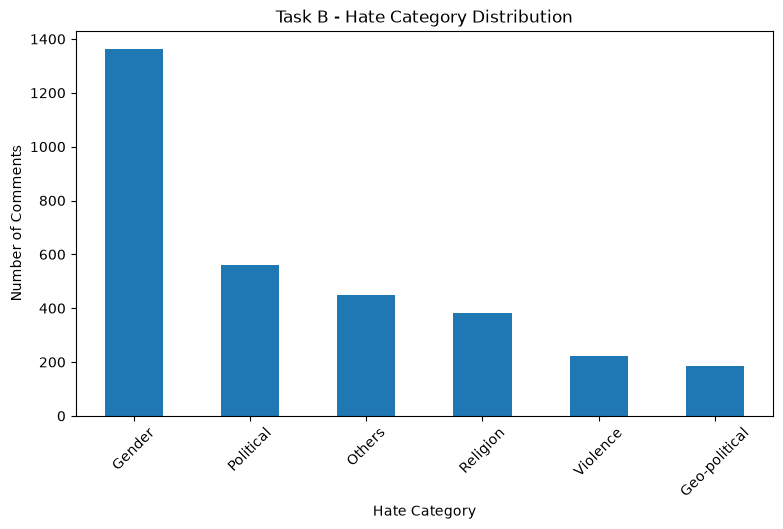

In [18]:
import matplotlib.pyplot as plt

# Task A
plt.figure(figsize=(7, 5))
binary_train["Label"].value_counts().plot(kind="bar")
plt.title("Task A - Hate vs Non-Hate")
plt.xlabel("Label")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.show()


# Task B
plt.figure(figsize=(9, 5))
multiclass_train["Hate Category"].value_counts().plot(kind="bar")
plt.title("Task B - Hate Category Distribution")
plt.xlabel("Hate Category")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.show()

# comment length analysis & preprocessing

In [19]:
# Comment length analysis

for df in [binary_train, multiclass_train]:
    df["char_length"] = df["Comment_clean"].str.len()
    df["word_count"] = df["Comment_clean"].str.split().str.len()


print("=" * 60)
print("TASK A - BINARY TRAIN")
print("=" * 60)

print(binary_train[["char_length", "word_count"]].describe())


print("\n" + "=" * 60)
print("TASK B - MULTICLASS TRAIN")
print("=" * 60)

print(multiclass_train[["char_length", "word_count"]].describe())

TASK A - BINARY TRAIN
       char_length   word_count
count  6446.000000  6446.000000
mean     74.725411    11.095098
std      76.173411    10.757534
min       5.000000     1.000000
25%      32.000000     5.000000
50%      52.000000     8.000000
75%      89.000000    13.000000
max    1084.000000   136.000000

TASK B - MULTICLASS TRAIN
       char_length   word_count
count  3159.000000  3159.000000
mean     87.047800    12.714783
std      82.622162    11.688077
min       7.000000     1.000000
25%      38.000000     6.000000
50%      61.000000     9.000000
75%     106.000000    15.000000
max     875.000000   128.000000


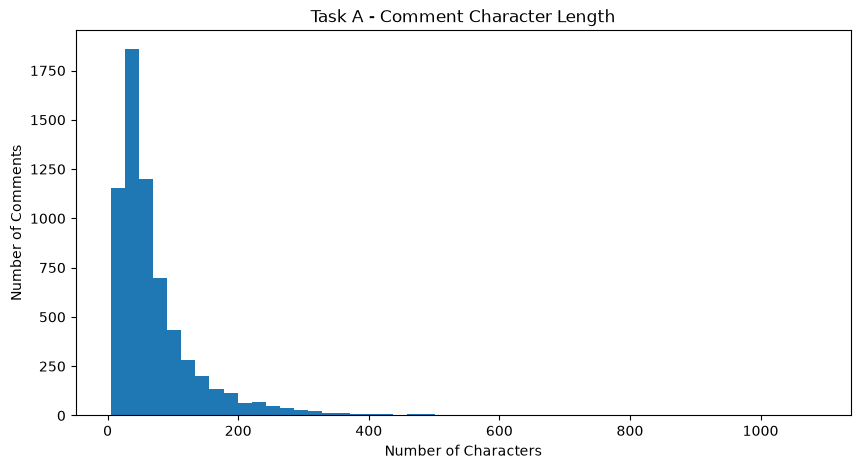

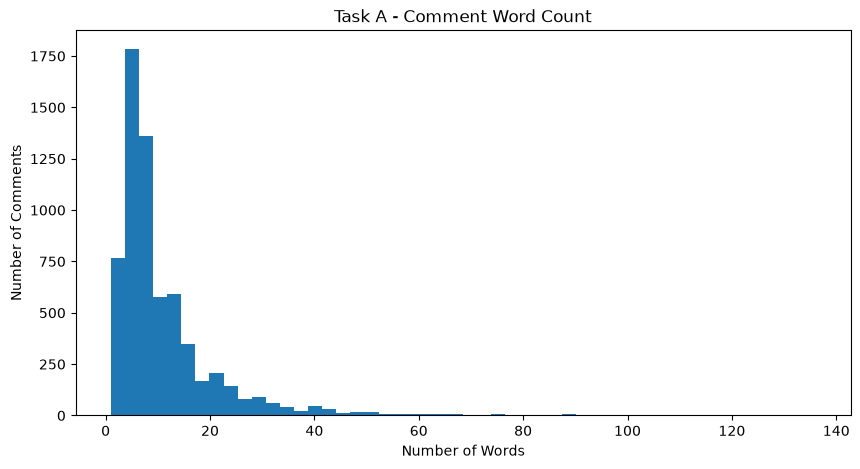

In [20]:
# Character length distribution

plt.figure(figsize=(10, 5))
plt.hist(binary_train["char_length"], bins=50)
plt.title("Task A - Comment Character Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Comments")
plt.show()


# Word count distribution

plt.figure(figsize=(10, 5))
plt.hist(binary_train["word_count"], bins=50)
plt.title("Task A - Comment Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Number of Comments")
plt.show()

In [21]:
# Check duplicate comments and their labels

print("=" * 70)
print("TASK A - DUPLICATE COMMENTS")
print("=" * 70)

duplicates_a = binary_train[
    binary_train["Comment_clean"].duplicated(keep=False)
].sort_values("Comment_clean")

display(duplicates_a[["Comment_clean", "Label"]])


print("\n" + "=" * 70)
print("TASK B - DUPLICATE COMMENTS")
print("=" * 70)

duplicates_b = multiclass_train[
    multiclass_train["Comment_clean"].duplicated(keep=False)
].sort_values("Comment_clean")

display(duplicates_b[["Comment_clean", "Hate Category"]])

TASK A - DUPLICATE COMMENTS


,Comment_clean,Label
4636,nim moun tulla randi magan,Hate
6149,nim moun tulla randi magan,Hate
2985,700 koti rajyada papulation?,Non-Hate
5179,700 koti rajyada papulation?,Non-Hate
4158,A hengadina miukha didare nachike agutte nama...,Hate
...,...,...
2806,"Swami , avaga yav govt ittu annodu heltiyalla....",Hate
2191,Yenne Congress Party Muduka😂😂😂😂😂😂👍,Hate
4390,Yenne Congress Party Muduka😂😂😂😂😂😂👍,Hate
5377,yena.rajakarnigalu..YEKVACHANADLI.MATHDTHI...A...,Hate



TASK B - DUPLICATE COMMENTS


,Comment_clean,Hate Category
1631,nim moun tulla randi magan,Gender
1751,nim moun tulla randi magan,Gender
396,Boli Maga na ninu csk fan na,Gender
1001,Boli Maga na ninu csk fan na,Gender
243,Dagar dagar dam dam dagar dagar sule ??,Gender
2636,Dagar dagar dam dam dagar dagar sule ??,Gender
1123,Dagar sonu,Gender
1135,Dagar sonu,Gender
2972,Dagar sonu,Gender
1801,Ivane dodda kala ivanu hatra hogi question kel...,Others


In [22]:
# Find duplicate comments with conflicting labels/categories

print("=" * 70)
print("TASK A - CONFLICTING DUPLICATES")
print("=" * 70)

conflicts_a = (
    binary_train.groupby("Comment_clean")["Label"]
    .nunique()
)

conflicts_a = conflicts_a[conflicts_a > 1]

print("Number of conflicting comments:", len(conflicts_a))


print("\n" + "=" * 70)
print("TASK B - CONFLICTING DUPLICATES")
print("=" * 70)

conflicts_b = (
    multiclass_train.groupby("Comment_clean")["Hate Category"]
    .nunique()
)

conflicts_b = conflicts_b[conflicts_b > 1]

print("Number of conflicting comments:", len(conflicts_b))

TASK A - CONFLICTING DUPLICATES
Number of conflicting comments: 3

TASK B - CONFLICTING DUPLICATES
Number of conflicting comments: 2


In [23]:
# Display all conflicting duplicate comments

print("=" * 70)
print("TASK A - CONFLICTING DUPLICATES")
print("=" * 70)

conflict_comments_a = (
    binary_train.groupby("Comment_clean")["Label"]
    .nunique()
)

conflict_comments_a = conflict_comments_a[
    conflict_comments_a > 1
].index

display(
    binary_train[
        binary_train["Comment_clean"].isin(conflict_comments_a)
    ][["Comment_clean", "Label"]]
    .sort_values("Comment_clean")
)


print("\n" + "=" * 70)
print("TASK B - CONFLICTING DUPLICATES")
print("=" * 70)

conflict_comments_b = (
    multiclass_train.groupby("Comment_clean")["Hate Category"]
    .nunique()
)

conflict_comments_b = conflict_comments_b[
    conflict_comments_b > 1
].index

display(
    multiclass_train[
        multiclass_train["Comment_clean"].isin(conflict_comments_b)
    ][["Comment_clean", "Hate Category"]]
    .sort_values("Comment_clean")
)

TASK A - CONFLICTING DUPLICATES


,Comment_clean,Label
5924,Ella cm thara evaru adjust aagilla adkke...,Hate
5970,Ella cm thara evaru adjust aagilla adkke...,Non-Hate
184,Ivanu jail inda bandaga en madidda gottillva n...,Hate
2644,Ivanu jail inda bandaga en madidda gottillva n...,Non-Hate
1124,Kangres gorment barbeku sidramyyasar cmagbeku ...,Hate
4121,Kangres gorment barbeku sidramyyasar cmagbeku ...,Non-Hate



TASK B - CONFLICTING DUPLICATES


,Comment_clean,Hate Category
582,Ninuna jilige hakidre desha rajyake nemdi ...,Geo-political
2287,Ninuna jilige hakidre desha rajyake nemdi ...,Political
108,Surprise enuo ellappa edhella namma janru madk...,Geo-political
248,Surprise enuo ellappa edhella namma janru madk...,Others


In [24]:
# Sample comments from each Task A class

print("=" * 70)
print("TASK A - SAMPLE COMMENTS")
print("=" * 70)

for label in ["Hate", "Non-Hate"]:
    print("\n" + "-" * 70)
    print(label)
    print("-" * 70)

    samples = binary_train[
        binary_train["Label"] == label
    ]["Comment_clean"].sample(
        n=10,
        random_state=42
    )

    for i, comment in enumerate(samples, 1):
        print(f"{i}. {comment}")

TASK A - SAMPLE COMMENTS

----------------------------------------------------------------------
Hate
----------------------------------------------------------------------
1. Entha avurunu yaru interview madala
2. @Seenu N le appi hogi maneli amma yendru madirthare tindubittu uchhe uyyidubittu malko ogu aste nin jeevana😂
3. Leee bevarsi nimkinta aa madrasi gale eshto vasi
4. Innentha math adtare nim antha backet hidkond views goskara thu nim makke
5. Innenu Intha kitthodhor na akondre disrespect bittre innen expect madthira? Ah ibbru lowdas name gothilla.. short hair girl and curly hair guy noduddhre mai mai mutkondu asayyadh chutiyas thara adthare. This is freaking family show where public audiences expects friendship, respect and manners. But this ott has none of these. Tv news chutiyagalge olle TRP and useless content. SUDEEP SIR ANTHU SONU GE CHAPPALI LI ODDHANG HELUDDHRU AVL MOKA NAYI HEL THINDHIRO THARA AGIDHE 😂🔥
6. Sule inu eshtu janaranna kondidalo
7. Nehru the true villan of 

In [25]:
# Sample comments from each Task B category

print("=" * 70)
print("TASK B - SAMPLE COMMENTS")
print("=" * 70)

categories = [
    "Gender",
    "Political",
    "Religion",
    "Geo-political",
    "Violence",
    "Others"
]

for category in categories:
    print("\n" + "-" * 70)
    print(category)
    print("-" * 70)

    samples = multiclass_train[
        multiclass_train["Hate Category"] == category
    ]["Comment_clean"].sample(
        n=min(10, len(multiclass_train[
            multiclass_train["Hate Category"] == category
        ])),
        random_state=42
    )

    for i, comment in enumerate(samples, 1):
        print(f"{i}. {comment}")

TASK B - SAMPLE COMMENTS

----------------------------------------------------------------------
Gender
----------------------------------------------------------------------
1. Mooru bittoru urge doddoru ?? ural yar yen helidru care madalla ee dove rani????????
2. Mostly ee btv  sonu relative avr channel ansutte???? adeng ivlna oglutare sadane sadane anta,oo god, channel avrge maryade idiya ,en kit dabakidald aa sonu , yav seeme celebrity avlu aa
3. Le lowdy siddu nin Sacha sule maga
4. Nin amma paapa kane yake lovede nin ammange value kodo soolemunde avra yedhurgadene kaal mele haaki  kari thullu thoristha idhiyalla thuu
5. Ivnyaro sule maga
6. Sonu matadod nodudre Tika ella uriyutte olle chaild tara adtale
7. No 1 dagar in Asia
8. Sule munde nA kyakarsi hugthu hatti avla ache ge
9. Sania mirza muradabad ppakistani loafer lady Jai kannada jai Karnataka ivalu tulli
10. Dagar dagar avl???? idu bittu bere  enilla

----------------------------------------------------------------------
Po

In [26]:
import html
import re

def clean_text(text):
    # Decode HTML entities
    text = html.unescape(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


binary_train["text"] = binary_train["Comment_clean"].apply(clean_text)
binary_val["text"] = binary_val["Comment_clean"].apply(clean_text)

multiclass_train["text"] = multiclass_train["Comment_clean"].apply(clean_text)
multiclass_val["text"] = multiclass_val["Comment_clean"].apply(clean_text)

print("Text cleaning completed.")

Text cleaning completed.


In [27]:
print(binary_train["text"].iloc[0])

Mir.Amarprasad nimage dhairya iddalli Sri rajiv dixit ravara kurithagi ondu video madi


In [28]:
import html
import re

def clean_text(text):
    # Decode HTML entities
    text = html.unescape(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


binary_train["text"] = binary_train["Comment_clean"].apply(clean_text)
binary_val["text"] = binary_val["Comment_clean"].apply(clean_text)

multiclass_train["text"] = multiclass_train["Comment_clean"].apply(clean_text)
multiclass_val["text"] = multiclass_val["Comment_clean"].apply(clean_text)

print("Text preprocessing completed.")

Text preprocessing completed.


In [30]:
print("Original:")
print(binary_train["Comment_clean"].iloc[0])

print("\nCleaned:")
print(binary_train["text"].iloc[0])

Original:
Mir.Amarprasad nimage dhairya iddalli Sri rajiv dixit ravara kurithagi ondu video madi

Cleaned:
Mir.Amarprasad nimage dhairya iddalli Sri rajiv dixit ravara kurithagi ondu video madi


# train val split

In [31]:
from sklearn.model_selection import train_test_split

# ============================================================
# TASK A - BINARY CLASSIFICATION
# ============================================================

X_a = binary_train["text"]
y_a = binary_train["Label"]

X_a_train, X_a_val, y_a_train, y_a_val = train_test_split(
    X_a,
    y_a,
    test_size=0.20,
    random_state=42,
    stratify=y_a
)


# ============================================================
# TASK B - MULTICLASS CLASSIFICATION
# ============================================================

X_b = multiclass_train["text"]
y_b = multiclass_train["Hate Category"]

X_b_train, X_b_val, y_b_train, y_b_val = train_test_split(
    X_b,
    y_b,
    test_size=0.20,
    random_state=42,
    stratify=y_b
)


# ============================================================
# CHECK SPLIT SIZES
# ============================================================

print("=" * 70)
print("TASK A - BINARY")
print("=" * 70)

print("Training samples   :", len(X_a_train))
print("Validation samples :", len(X_a_val))


print("\n" + "=" * 70)
print("TASK B - MULTICLASS")
print("=" * 70)

print("Training samples   :", len(X_b_train))
print("Validation samples :", len(X_b_val))

TASK A - BINARY
Training samples   : 5156
Validation samples : 1290

TASK B - MULTICLASS
Training samples   : 2527
Validation samples : 632


# task A

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# ============================================================
# TASK A - TF-IDF + LOGISTIC REGRESSION
# ============================================================

task_a_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Train
task_a_lr.fit(X_a_train, y_a_train)

print("Task A baseline model trained successfully.")

Task A baseline model trained successfully.


In [33]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ============================================================
# TASK A - BASELINE EVALUATION
# ============================================================

# Predict validation data
y_a_pred = task_a_lr.predict(X_a_val)

# Calculate metrics
accuracy = accuracy_score(y_a_val, y_a_pred)
macro_f1 = f1_score(y_a_val, y_a_pred, average="macro")

print("=" * 70)
print("TASK A - TF-IDF + LOGISTIC REGRESSION")
print("=" * 70)

print(f"Accuracy : {accuracy:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_a_val, y_a_pred))

TASK A - TF-IDF + LOGISTIC REGRESSION
Accuracy : 0.7667
Macro F1 : 0.7665

Classification Report:
              precision    recall  f1-score   support

        Hate       0.77      0.75      0.76       632
    Non-Hate       0.77      0.78      0.77       658

    accuracy                           0.77      1290
   macro avg       0.77      0.77      0.77      1290
weighted avg       0.77      0.77      0.77      1290



In [34]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# ============================================================
# TASK A - CHARACTER TF-IDF + LINEAR SVM
# ============================================================

task_a_char_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(3, 5),
        min_df=2,
        sublinear_tf=True
    )),
    
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

# Train
task_a_char_svm.fit(X_a_train, y_a_train)

print("Task A Character TF-IDF + Linear SVM trained successfully.")

Task A Character TF-IDF + Linear SVM trained successfully.


In [35]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ============================================================
# TASK A - CHARACTER TF-IDF + LINEAR SVM EVALUATION
# ============================================================

y_a_char_pred = task_a_char_svm.predict(X_a_val)

accuracy_char = accuracy_score(y_a_val, y_a_char_pred)
macro_f1_char = f1_score(y_a_val, y_a_char_pred, average="macro")

print("=" * 70)
print("TASK A - CHARACTER TF-IDF + LINEAR SVM")
print("=" * 70)

print(f"Accuracy : {accuracy_char:.4f}")
print(f"Macro F1 : {macro_f1_char:.4f}")

print("\nClassification Report:")
print(classification_report(y_a_val, y_a_char_pred))

TASK A - CHARACTER TF-IDF + LINEAR SVM
Accuracy : 0.8047
Macro F1 : 0.8043

Classification Report:
              precision    recall  f1-score   support

        Hate       0.81      0.78      0.80       632
    Non-Hate       0.80      0.83      0.81       658

    accuracy                           0.80      1290
   macro avg       0.81      0.80      0.80      1290
weighted avg       0.81      0.80      0.80      1290



In [36]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# ============================================================
# TASK A - WORD + CHARACTER TF-IDF + LINEAR SVM
# ============================================================

combined_features = FeatureUnion([
    ("word", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    
    ("char", TfidfVectorizer(
        analyzer="char",
        ngram_range=(3, 5),
        min_df=2,
        sublinear_tf=True
    ))
])

task_a_combined_svm = Pipeline([
    ("features", combined_features),
    
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

# Train
task_a_combined_svm.fit(X_a_train, y_a_train)

print("Task A Word + Character TF-IDF + Linear SVM trained successfully.")

Task A Word + Character TF-IDF + Linear SVM trained successfully.


In [37]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ============================================================
# TASK A - WORD + CHARACTER TF-IDF + LINEAR SVM EVALUATION
# ============================================================

y_a_combined_pred = task_a_combined_svm.predict(X_a_val)

accuracy_combined = accuracy_score(y_a_val, y_a_combined_pred)
macro_f1_combined = f1_score(
    y_a_val,
    y_a_combined_pred,
    average="macro"
)

print("=" * 70)
print("TASK A - WORD + CHARACTER TF-IDF + LINEAR SVM")
print("=" * 70)

print(f"Accuracy : {accuracy_combined:.4f}")
print(f"Macro F1 : {macro_f1_combined:.4f}")

print("\nClassification Report:")
print(classification_report(y_a_val, y_a_combined_pred))

TASK A - WORD + CHARACTER TF-IDF + LINEAR SVM
Accuracy : 0.7915
Macro F1 : 0.7910

Classification Report:
              precision    recall  f1-score   support

        Hate       0.80      0.76      0.78       632
    Non-Hate       0.78      0.82      0.80       658

    accuracy                           0.79      1290
   macro avg       0.79      0.79      0.79      1290
weighted avg       0.79      0.79      0.79      1290



In [38]:
# ============================================================
# TASK A - ERROR ANALYSIS
# ============================================================

error_analysis_a = pd.DataFrame({
    "text": X_a_val,
    "actual": y_a_val,
    "predicted": y_a_char_pred
})

# False Positives
false_positives = error_analysis_a[
    (error_analysis_a["actual"] == "Non-Hate") &
    (error_analysis_a["predicted"] == "Hate")
]

# False Negatives
false_negatives = error_analysis_a[
    (error_analysis_a["actual"] == "Hate") &
    (error_analysis_a["predicted"] == "Non-Hate")
]

print("=" * 70)
print("TASK A - ERROR ANALYSIS")
print("=" * 70)

print(f"False Positives : {len(false_positives)}")
print(f"False Negatives : {len(false_negatives)}")

print("\n" + "=" * 70)
print("FALSE POSITIVES - Non-Hate predicted as Hate")
print("=" * 70)

display(false_positives[["text", "actual", "predicted"]].head(20))

print("\n" + "=" * 70)
print("FALSE NEGATIVES - Hate predicted as Non-Hate")
print("=" * 70)

display(false_negatives[["text", "actual", "predicted"]].head(20))

TASK A - ERROR ANALYSIS
False Positives : 112
False Negatives : 140

FALSE POSITIVES - Non-Hate predicted as Hate


,text,actual,predicted
1066,Innu swalpa dina Johnny sins karstare btv avru😃😃,Non-Hate,Hate
1724,CM avarige gotide thathaya adare stana goskara...,Non-Hate,Hate
2420,Super...avar lifelli nadediruvudu avrige gottu...,Non-Hate,Hate
4513,Anna yar adru modlu sonu na yar adru antarica ...,Non-Hate,Hate
5970,Ella cm thara evaru adjust aagilla adkke...,Non-Hate,Hate
693,Le tv 9 alle muniswamy help maadta eorodu,Non-Hate,Hate
4813,😂 Kohili first young players na sledge madodu ...,Non-Hate,Hate
4816,Nammalli oggattu illa,Non-Hate,Hate
1614,Thayige first mariyade kodu,Non-Hate,Hate
5070,5:06 innen madtare inta maglu uttidmele,Non-Hate,Hate



FALSE NEGATIVES - Hate predicted as Non-Hate


,text,actual,predicted
4344,uta neeru kodbedi aaga kannada barutthe??,Hate,Non-Hate
1053,E movie nodudre yare agirli rakhta kudiyuthe p...,Hate,Non-Hate
2383,Avanu chai mare gottilla vadhare neenu hudigiy...,Hate,Non-Hate
4301,Sariyagi kaydre currect agtale,Hate,Non-Hate
5877,muduka enu gottilde matadodu tappu. Hindu dhar...,Hate,Non-Hate
1800,Lo mudeya avarava ooralli avaray gelodhu,Hate,Non-Hate
1182,Papa hdk kumaraswamy avanige bari 1kg mutton t...,Hate,Non-Hate
3461,Hindu virodi,Hate,Non-Hate
1124,Kangres gorment barbeku sidramyyasar cmagbeku ...,Hate,Non-Hate
2729,"Swami , avaga yav govt ittu annodu heltiyalla....",Hate,Non-Hate


In [39]:
# ============================================================
# TASK A - EXPERIMENT RESULTS
# ============================================================

task_a_results = pd.DataFrame([
    {
        "Model": "Word TF-IDF + Logistic Regression",
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    },
    {
        "Model": "Character TF-IDF + Linear SVM",
        "Accuracy": accuracy_char,
        "Macro F1": macro_f1_char
    },
    {
        "Model": "Word + Character TF-IDF + Linear SVM",
        "Accuracy": accuracy_combined,
        "Macro F1": macro_f1_combined
    }
])

display(
    task_a_results.sort_values(
        "Macro F1",
        ascending=False
    ).reset_index(drop=True)
)

,Model,Accuracy,Macro F1
0,Character TF-IDF + Linear SVM,0.804651,0.804308
1,Word + Character TF-IDF + Linear SVM,0.791473,0.791006
2,Word TF-IDF + Logistic Regression,0.766667,0.766453


In [41]:
# ============================================================
# TASK A - XLM-RoBERTa SETUP
# ============================================================

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "xlm-roberta-base"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load model for binary classification
task_a_xlmr = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
task_a_xlmr = task_a_xlmr.to(device)

print("=" * 70)
print("XLM-RoBERTa SETUP")
print("=" * 70)
print("Model  :", MODEL_NAME)
print("Device :", device)
print("Labels :", task_a_xlmr.config.num_labels)
print("Tokenizer loaded successfully.")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5386.50it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLM-RoBERTa SETUP
Model  : xlm-roberta-base
Device : cuda
Labels : 2
Tokenizer loaded successfully.


In [42]:
# ============================================================
# TASK A - XLM-R TOKENIZATION
# ============================================================

MAX_LENGTH = 128

# Tokenize training data
train_encodings = tokenizer(
    X_a_train.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

# Tokenize validation data
val_encodings = tokenizer(
    X_a_val.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

print("=" * 70)
print("TASK A - TOKENIZATION")
print("=" * 70)

print("Training samples   :", len(train_encodings["input_ids"]))
print("Validation samples :", len(val_encodings["input_ids"]))
print("Maximum length     :", MAX_LENGTH)

print("\nExample token IDs:")
print(train_encodings["input_ids"][0][:20])

TASK A - TOKENIZATION
Training samples   : 5156
Validation samples : 1290
Maximum length     : 128

Example token IDs:
[0, 59285, 2967, 151, 183835, 167388, 53, 5952, 5, 5, 32694, 129083, 10, 693, 2967, 986, 5, 115114, 115114, 115114]


In [43]:
# ============================================================
# TASK A - CREATE PYTORCH DATASET
# ============================================================

import torch
from torch.utils.data import Dataset


class HASTIKADataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item


# Convert labels to numerical IDs
label_map_a = {
    "Non-Hate": 0,
    "Hate": 1
}

y_a_train_encoded = y_a_train.map(label_map_a)
y_a_val_encoded = y_a_val.map(label_map_a)


# Create datasets
train_dataset_a = HASTIKADataset(
    train_encodings,
    y_a_train_encoded
)

val_dataset_a = HASTIKADataset(
    val_encodings,
    y_a_val_encoded
)


print("=" * 70)
print("TASK A - PYTORCH DATASET")
print("=" * 70)

print("Training dataset   :", len(train_dataset_a))
print("Validation dataset :", len(val_dataset_a))

print("\nLabel mapping:")
print(label_map_a)

print("\nExample:")
print(train_dataset_a[0])

TASK A - PYTORCH DATASET
Training dataset   : 5156
Validation dataset : 1290

Label mapping:
{'Non-Hate': 0, 'Hate': 1}

Example:
{'input_ids': tensor([     0,  59285,   2967,    151, 183835, 167388,     53,   5952,      5,
             5,  32694, 129083,     10,    693,   2967,    986,      5, 115114,
        115114, 115114,      2,      1,      1,      1,      1,      1,      1,
             1,      1,      1,      1,      1,      1,      1,      1,      1,
             1,      1,      1,      1,      1,      1,      1,      1,      1,
             1,      1,      1,      1,      1,      1,      1,      1,      1,
             1,      1,      1,      1,      1,      1,      1,      1,      1,
             1,      1,      1,      1,      1,      1,      1,      1,      1,
             1,      1,      1,      1,      1,      1,      1,      1,      1,
             1,      1,      1,      1,      1,      1,      1,      1,      1,
             1,      1,      1,      1,      1,      1, 

In [50]:
# ============================================================
# TASK A - CREATE DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_loader_a = DataLoader(
    train_dataset_a,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

val_loader_a = DataLoader(
    val_dataset_a,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

print("=" * 70)
print("TASK A - DATALOADERS")
print("=" * 70)

print("Batch size        :", BATCH_SIZE)
print("Training batches  :", len(train_loader_a))
print("Validation batches:", len(val_loader_a))

TASK A - DATALOADERS
Batch size        : 8
Training batches  : 645
Validation batches: 162


In [51]:
# ============================================================
# TASK A - XLM-R OPTIMIZED TRAINING
# ============================================================

from tqdm.auto import tqdm
from sklearn.metrics import f1_score
import torch

EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

optimizer = torch.optim.AdamW(
    task_a_xlmr.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Mixed precision
scaler = torch.amp.GradScaler("cuda")

best_macro_f1 = 0.0
best_state = None

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------
    task_a_xlmr.train()
    total_train_loss = 0.0

    progress_bar = tqdm(
        train_loader_a,
        desc=f"Epoch {epoch + 1}/{EPOCHS} - Training"
    )

    for batch in progress_bar:

        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision
        with torch.amp.autocast("cuda"):
            outputs = task_a_xlmr(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    avg_train_loss = total_train_loss / len(train_loader_a)

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------
    task_a_xlmr.eval()

    val_predictions = []
    val_labels = []

    with torch.no_grad():

        for batch in tqdm(
            val_loader_a,
            desc=f"Epoch {epoch + 1}/{EPOCHS} - Validation"
        ):

            input_ids = batch["input_ids"].to(device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)
            labels = batch["labels"].to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = task_a_xlmr(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

            predictions = torch.argmax(
                outputs.logits,
                dim=1
            )

            val_predictions.extend(
                predictions.cpu().numpy()
            )

            val_labels.extend(
                labels.cpu().numpy()
            )

    val_macro_f1 = f1_score(
        val_labels,
        val_predictions,
        average="macro"
    )

    # --------------------------------------------------------
    # RESULTS
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"EPOCH {epoch + 1}/{EPOCHS}")
    print("=" * 70)
    print(f"Training Loss : {avg_train_loss:.4f}")
    print(f"Validation F1 : {val_macro_f1:.4f}")

    # Save best model
    if val_macro_f1 > best_macro_f1:

        best_macro_f1 = val_macro_f1

        best_state = {
            key: value.detach().cpu().clone()
            for key, value in task_a_xlmr.state_dict().items()
        }

        print("★ New best model saved in memory.")

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)
print(f"Best Validation Macro-F1 : {best_macro_f1:.4f}")

Epoch 1/3 - Validation: 100%|██████████| 162/162 [02:03<00:00,  1.31it/s]



EPOCH 1/3
Training Loss : 0.6405
Validation F1 : 0.7285
★ New best model saved in memory.


Epoch 2/3 - Training:   2%|▏         | 14/645 [01:23<1:02:38,  5.96s/it, loss=0.5352]


KeyboardInterrupt: 

# task B

In [52]:
# ============================================================
# TASK B - CLASS DISTRIBUTION
# ============================================================

print("=" * 70)
print("TASK B - HATE CATEGORY DISTRIBUTION")
print("=" * 70)

print("\nTraining set:")
print(y_b_train.value_counts())

print("\nTraining set percentages:")
print(
    (y_b_train.value_counts(normalize=True) * 100)
    .round(2)
)

print("\nValidation set:")
print(y_b_val.value_counts())

print("\nValidation set percentages:")
print(
    (y_b_val.value_counts(normalize=True) * 100)
    .round(2)
)

TASK B - HATE CATEGORY DISTRIBUTION

Training set:
Hate Category
Gender           1089
Political         447
Others            359
Religion          306
Violence          177
Geo-political     149
Name: count, dtype: int64

Training set percentages:
Hate Category
Gender           43.09
Political        17.69
Others           14.21
Religion         12.11
Violence          7.00
Geo-political     5.90
Name: proportion, dtype: float64

Validation set:
Hate Category
Gender           273
Political        112
Others            90
Religion          76
Violence          44
Geo-political     37
Name: count, dtype: int64

Validation set percentages:
Hate Category
Gender           43.20
Political        17.72
Others           14.24
Religion         12.03
Violence          6.96
Geo-political     5.85
Name: proportion, dtype: float64


In [53]:
# ============================================================
# TASK B - CHARACTER TF-IDF + LINEAR SVM
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

task_b_char_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(3, 5),
        min_df=2,
        sublinear_tf=True
    )),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

task_b_char_svm.fit(
    X_b_train,
    y_b_train
)

print("=" * 70)
print("TASK B - MODEL TRAINING COMPLETE")
print("=" * 70)
print("Model: Character TF-IDF + Linear SVM")

TASK B - MODEL TRAINING COMPLETE
Model: Character TF-IDF + Linear SVM


In [54]:
# ============================================================
# TASK B - MODEL 1 EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

# Predictions
y_b_pred = task_b_char_svm.predict(X_b_val)

# Metrics
accuracy_b = accuracy_score(y_b_val, y_b_pred)

macro_f1_b = f1_score(
    y_b_val,
    y_b_pred,
    average="macro"
)

print("=" * 70)
print("TASK B - CHARACTER TF-IDF + LINEAR SVM")
print("=" * 70)

print(f"Accuracy : {accuracy_b:.4f}")
print(f"Macro F1 : {macro_f1_b:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_b_val,
        y_b_pred
    )
)

TASK B - CHARACTER TF-IDF + LINEAR SVM
Accuracy : 0.6851
Macro F1 : 0.5756

Classification Report:
               precision    recall  f1-score   support

       Gender       0.75      0.86      0.80       273
Geo-political       0.53      0.46      0.49        37
       Others       0.49      0.39      0.43        90
    Political       0.72      0.75      0.74       112
     Religion       0.71      0.70      0.70        76
     Violence       0.40      0.23      0.29        44

     accuracy                           0.69       632
    macro avg       0.60      0.56      0.58       632
 weighted avg       0.67      0.69      0.67       632



In [55]:
# ============================================================
# TASK B - WORD TF-IDF + LINEAR SVM
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

task_b_word_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

task_b_word_svm.fit(
    X_b_train,
    y_b_train
)

print("=" * 70)
print("TASK B - WORD TF-IDF + LINEAR SVM")
print("=" * 70)
print("Model training complete.")

TASK B - WORD TF-IDF + LINEAR SVM
Model training complete.


In [56]:
# ============================================================
# TASK B - WORD TF-IDF + LINEAR SVM EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

# Predictions
y_b_word_pred = task_b_word_svm.predict(X_b_val)

# Metrics
accuracy_b_word = accuracy_score(
    y_b_val,
    y_b_word_pred
)

macro_f1_b_word = f1_score(
    y_b_val,
    y_b_word_pred,
    average="macro"
)

print("=" * 70)
print("TASK B - WORD TF-IDF + LINEAR SVM")
print("=" * 70)

print(f"Accuracy : {accuracy_b_word:.4f}")
print(f"Macro F1 : {macro_f1_b_word:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_b_val,
        y_b_word_pred
    )
)

TASK B - WORD TF-IDF + LINEAR SVM
Accuracy : 0.6234
Macro F1 : 0.5447

Classification Report:
               precision    recall  f1-score   support

       Gender       0.73      0.75      0.74       273
Geo-political       0.58      0.59      0.59        37
       Others       0.34      0.31      0.32        90
    Political       0.72      0.67      0.69       112
     Religion       0.59      0.67      0.63        76
     Violence       0.32      0.27      0.29        44

     accuracy                           0.62       632
    macro avg       0.55      0.55      0.54       632
 weighted avg       0.62      0.62      0.62       632



In [57]:
# ============================================================
# TASK B - WORD + CHARACTER TF-IDF + LINEAR SVM
# ============================================================

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

task_b_combined_features = FeatureUnion([
    ("word", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ("char", TfidfVectorizer(
        analyzer="char",
        ngram_range=(3, 5),
        min_df=2,
        sublinear_tf=True
    ))
])

task_b_combined_svm = Pipeline([
    ("features", task_b_combined_features),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

task_b_combined_svm.fit(
    X_b_train,
    y_b_train
)

print("=" * 70)
print("TASK B - WORD + CHARACTER TF-IDF + LINEAR SVM")
print("=" * 70)
print("Model training complete.")

TASK B - WORD + CHARACTER TF-IDF + LINEAR SVM
Model training complete.


In [58]:
# ============================================================
# TASK B - WORD + CHARACTER TF-IDF + LINEAR SVM EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

# Predictions
y_b_combined_pred = task_b_combined_svm.predict(X_b_val)

# Metrics
accuracy_b_combined = accuracy_score(
    y_b_val,
    y_b_combined_pred
)

macro_f1_b_combined = f1_score(
    y_b_val,
    y_b_combined_pred,
    average="macro"
)

print("=" * 70)
print("TASK B - WORD + CHARACTER TF-IDF + LINEAR SVM")
print("=" * 70)

print(f"Accuracy : {accuracy_b_combined:.4f}")
print(f"Macro F1 : {macro_f1_b_combined:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_b_val,
        y_b_combined_pred
    )
)

TASK B - WORD + CHARACTER TF-IDF + LINEAR SVM
Accuracy : 0.6756
Macro F1 : 0.5733

Classification Report:
               precision    recall  f1-score   support

       Gender       0.76      0.84      0.80       273
Geo-political       0.53      0.49      0.51        37
       Others       0.38      0.34      0.36        90
    Political       0.74      0.74      0.74       112
     Religion       0.70      0.72      0.71        76
     Violence       0.46      0.25      0.32        44

     accuracy                           0.68       632
    macro avg       0.59      0.56      0.57       632
 weighted avg       0.66      0.68      0.66       632



In [59]:
# ============================================================
# TASK B - CHARACTER SVM HYPERPARAMETER TUNING
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

C_VALUES = [0.25, 0.5, 1.0, 1.5, 2.0]

results_b = []

for C in C_VALUES:

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True
        )),
        ("classifier", LinearSVC(
            C=C,
            class_weight="balanced",
            random_state=42
        ))
    ])

    model.fit(X_b_train, y_b_train)

    pred = model.predict(X_b_val)

    accuracy = accuracy_score(y_b_val, pred)
    macro_f1 = f1_score(
        y_b_val,
        pred,
        average="macro"
    )

    results_b.append({
        "C": C,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })

    print(
        f"C={C:<4} | "
        f"Accuracy={accuracy:.4f} | "
        f"Macro F1={macro_f1:.4f}"
    )

C=0.25 | Accuracy=0.6835 | Macro F1=0.5822
C=0.5  | Accuracy=0.6867 | Macro F1=0.5793
C=1.0  | Accuracy=0.6851 | Macro F1=0.5756
C=1.5  | Accuracy=0.6756 | Macro F1=0.5699
C=2.0  | Accuracy=0.6725 | Macro F1=0.5644


In [60]:
# ============================================================
# TASK B - CHARACTER N-GRAM TUNING
# Best C so far = 0.25
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

NGRAM_RANGES = [
    (2, 5),
    (3, 5),
    (3, 6),
    (2, 6)
]

ngram_results_b = []

for ngram_range in NGRAM_RANGES:

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char",
            ngram_range=ngram_range,
            min_df=2,
            sublinear_tf=True
        )),
        ("classifier", LinearSVC(
            C=0.25,
            class_weight="balanced",
            random_state=42
        ))
    ])

    model.fit(X_b_train, y_b_train)

    pred = model.predict(X_b_val)

    accuracy = accuracy_score(y_b_val, pred)
    macro_f1 = f1_score(
        y_b_val,
        pred,
        average="macro"
    )

    ngram_results_b.append({
        "ngram_range": str(ngram_range),
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })

    print(
        f"n-gram={ngram_range} | "
        f"Accuracy={accuracy:.4f} | "
        f"Macro F1={macro_f1:.4f}"
    )

n-gram=(2, 5) | Accuracy=0.6946 | Macro F1=0.5992
n-gram=(3, 5) | Accuracy=0.6835 | Macro F1=0.5822
n-gram=(3, 6) | Accuracy=0.6835 | Macro F1=0.5817
n-gram=(2, 6) | Accuracy=0.6978 | Macro F1=0.5978


In [61]:
# ============================================================
# TASK B - MIN_DF TUNING
# Best so far: char (2,5) + C=0.25
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

MIN_DF_VALUES = [1, 2, 3, 5]

mindf_results_b = []

for min_df in MIN_DF_VALUES:

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char",
            ngram_range=(2, 5),
            min_df=min_df,
            sublinear_tf=True
        )),
        ("classifier", LinearSVC(
            C=0.25,
            class_weight="balanced",
            random_state=42
        ))
    ])

    model.fit(X_b_train, y_b_train)

    pred = model.predict(X_b_val)

    accuracy = accuracy_score(y_b_val, pred)
    macro_f1 = f1_score(
        y_b_val,
        pred,
        average="macro"
    )

    mindf_results_b.append({
        "min_df": min_df,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })

    print(
        f"min_df={min_df} | "
        f"Accuracy={accuracy:.4f} | "
        f"Macro F1={macro_f1:.4f}"
    )

min_df=1 | Accuracy=0.6994 | Macro F1=0.6044
min_df=2 | Accuracy=0.6946 | Macro F1=0.5992
min_df=3 | Accuracy=0.6915 | Macro F1=0.5918
min_df=5 | Accuracy=0.6851 | Macro F1=0.5881


In [62]:
# ============================================================
# TASK B - SUBLINEAR TF TUNING
# Best so far:
# char n-gram (2,5)
# C = 0.25
# min_df = 1
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

SUBLINEAR_VALUES = [False, True]

sublinear_results_b = []

for sublinear in SUBLINEAR_VALUES:

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char",
            ngram_range=(2, 5),
            min_df=1,
            sublinear_tf=sublinear
        )),
        ("classifier", LinearSVC(
            C=0.25,
            class_weight="balanced",
            random_state=42
        ))
    ])

    model.fit(X_b_train, y_b_train)

    pred = model.predict(X_b_val)

    accuracy = accuracy_score(y_b_val, pred)
    macro_f1 = f1_score(
        y_b_val,
        pred,
        average="macro"
    )

    sublinear_results_b.append({
        "sublinear_tf": sublinear,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })

    print(
        f"sublinear_tf={sublinear} | "
        f"Accuracy={accuracy:.4f} | "
        f"Macro F1={macro_f1:.4f}"
    )

sublinear_tf=False | Accuracy=0.6978 | Macro F1=0.5997
sublinear_tf=True | Accuracy=0.6994 | Macro F1=0.6044


In [63]:
# ============================================================
# TASK B - MAX_FEATURES TUNING
# Best so far:
# char (2,5) + C=0.25 + min_df=1 + sublinear_tf=True
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

MAX_FEATURES_VALUES = [
    None,
    50000,
    100000,
    200000
]

max_features_results_b = []

for max_features in MAX_FEATURES_VALUES:

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char",
            ngram_range=(2, 5),
            min_df=1,
            sublinear_tf=True,
            max_features=max_features
        )),
        ("classifier", LinearSVC(
            C=0.25,
            class_weight="balanced",
            random_state=42
        ))
    ])

    model.fit(X_b_train, y_b_train)

    pred = model.predict(X_b_val)

    accuracy = accuracy_score(y_b_val, pred)
    macro_f1 = f1_score(
        y_b_val,
        pred,
        average="macro"
    )

    max_features_results_b.append({
        "max_features": max_features,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })

    print(
        f"max_features={max_features} | "
        f"Accuracy={accuracy:.4f} | "
        f"Macro F1={macro_f1:.4f}"
    )

max_features=None | Accuracy=0.6994 | Macro F1=0.6044
max_features=50000 | Accuracy=0.6962 | Macro F1=0.5998
max_features=100000 | Accuracy=0.7009 | Macro F1=0.6052
max_features=200000 | Accuracy=0.6994 | Macro F1=0.6044


In [64]:
# ============================================================
# TASK B - BEST MODEL
# Character TF-IDF + Linear SVM
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

task_b_best = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(2, 5),
        min_df=1,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", LinearSVC(
        C=0.25,
        class_weight="balanced",
        random_state=42
    ))
])

task_b_best.fit(
    X_b_train,
    y_b_train
)

y_b_best_pred = task_b_best.predict(X_b_val)

print("=" * 70)
print("TASK B - BEST MODEL")
print("=" * 70)

print(f"Accuracy : {accuracy_score(y_b_val, y_b_best_pred):.4f}")
print(f"Macro F1 : {f1_score(y_b_val, y_b_best_pred, average='macro'):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_b_val,
        y_b_best_pred
    )
)

TASK B - BEST MODEL
Accuracy : 0.7009
Macro F1 : 0.6052

Classification Report:
               precision    recall  f1-score   support

       Gender       0.75      0.88      0.81       273
Geo-political       0.59      0.62      0.61        37
       Others       0.52      0.37      0.43        90
    Political       0.76      0.72      0.74       112
     Religion       0.69      0.71      0.70        76
     Violence       0.46      0.27      0.34        44

     accuracy                           0.70       632
    macro avg       0.63      0.60      0.61       632
 weighted avg       0.68      0.70      0.69       632



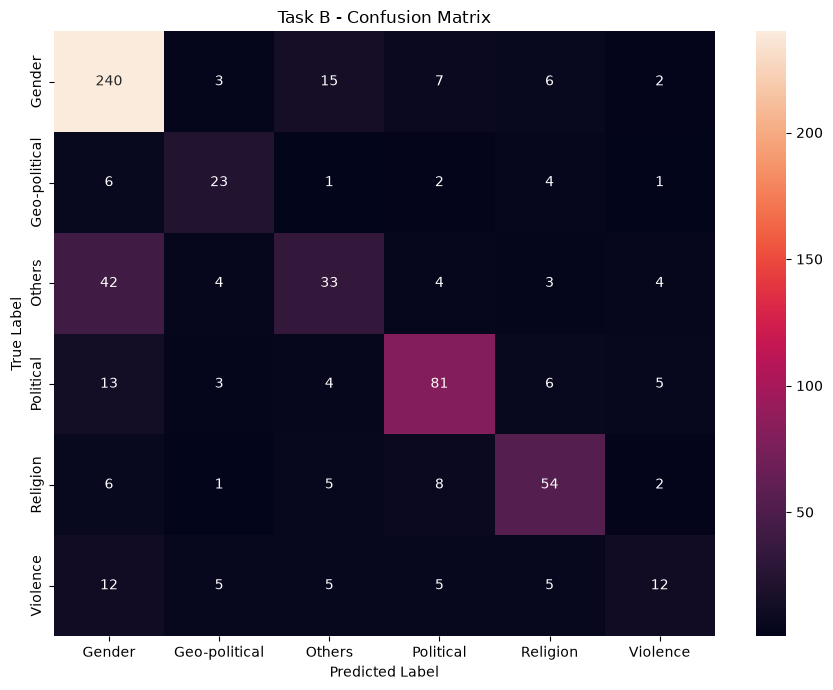

In [65]:
# ============================================================
# TASK B - CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels_b = [
    "Gender",
    "Geo-political",
    "Others",
    "Political",
    "Religion",
    "Violence"
]

cm_b = confusion_matrix(
    y_b_val,
    y_b_best_pred,
    labels=labels_b
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_b,
    annot=True,
    fmt="d",
    xticklabels=labels_b,
    yticklabels=labels_b
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Task B - Confusion Matrix")
plt.tight_layout()
plt.show()

In [66]:
# ============================================================
# TASK B - CONFUSION MATRIX (NUMBER GRID)
# ============================================================

from sklearn.metrics import confusion_matrix
import pandas as pd

labels_b = [
    "Gender",
    "Geo-political",
    "Others",
    "Political",
    "Religion",
    "Violence"
]

cm_b = confusion_matrix(
    y_b_val,
    y_b_best_pred,
    labels=labels_b
)

# Display as a grid
cm_df = pd.DataFrame(
    cm_b,
    index=labels_b,
    columns=labels_b
)

print("Task B - Confusion Matrix")
print(cm_df)

Task B - Confusion Matrix
               Gender  Geo-political  Others  Political  Religion  Violence
Gender            240              3      15          7         6         2
Geo-political       6             23       1          2         4         1
Others             42              4      33          4         3         4
Political          13              3       4         81         6         5
Religion            6              1       5          8        54         2
Violence           12              5       5          5         5        12


In [67]:
# ============================================================
# TASK B - VIOLENCE ERROR ANALYSIS
# ============================================================

import pandas as pd

error_analysis_b = pd.DataFrame({
    "text": X_b_val.values,
    "actual": y_b_val.values,
    "predicted": y_b_best_pred
})

violence_errors = error_analysis_b[
    (error_analysis_b["actual"] == "Violence") &
    (error_analysis_b["predicted"] != "Violence")
].copy()

print("=" * 70)
print("VIOLENCE MISCLASSIFICATIONS")
print("=" * 70)

print(f"Total Violence samples : {(y_b_val == 'Violence').sum()}")
print(f"Correctly classified   : {(y_b_best_pred[y_b_val.values == 'Violence'] == 'Violence').sum()}")
print(f"Misclassified          : {len(violence_errors)}")

display(
    violence_errors[
        ["text", "predicted"]
    ].reset_index(drop=True)
)

VIOLENCE MISCLASSIFICATIONS
Total Violence samples : 44
Correctly classified   : 12
Misclassified          : 32


,text,predicted
0,Huchcha ee tara galabhe ella ebbisi en sadhastiya,Gender
1,Adikke vayasadamele buddi kadime aagutte andu ...,Gender
2,Niinu fast sathoogu avagala karanataka channag...,Gender
3,Ondu kelsa madana aunu yalle erli tandu kochi ...,Gender
4,"Gujrat files, 1992 files, mumbai files, sikh r...",Religion
5,underworld don muttappa Rai du party ante guru,Political
6,Naveen reddy magane namma Kohli touch madidre ...,Gender
7,Ayyo sulemakla nimge sulle ellavngu bega idsod...,Gender
8,KACHADA NAYIGALIGE ENTHA KETTA WORD AKIDRU NAN...,Others
9,Le hoge muslim ugragami soolemunde🤧🤧,Religion


In [68]:
# ============================================================
# TASK B - VIOLENCE: CORRECT VS INCORRECT
# ============================================================

violence_all = error_analysis_b[
    error_analysis_b["actual"] == "Violence"
].copy()

correct_violence = violence_all[
    violence_all["predicted"] == "Violence"
].copy()

incorrect_violence = violence_all[
    violence_all["predicted"] != "Violence"
].copy()

print("=" * 70)
print("CORRECTLY CLASSIFIED VIOLENCE")
print("=" * 70)

display(
    correct_violence[
        ["text", "predicted"]
    ].reset_index(drop=True)
)

print("\n" + "=" * 70)
print("INCORRECTLY CLASSIFIED VIOLENCE")
print("=" * 70)

display(
    incorrect_violence[
        ["text", "predicted"]
    ].reset_index(drop=True)
)

CORRECTLY CLASSIFIED VIOLENCE


,text,predicted
0,Nam government en madtide ee tara agtirodella ...,Violence
1,raja Hari Singh madiddrinda ishtella agtirodu ...,Violence
2,A ugragamina saha ella kallinda hodidu sayisbe...,Violence
3,"Avanannu hagene kollabeku,avana kutumbavannu b...",Violence
4,Muni mulegump agtane ee dushkarmi galanna matt...,Violence
5,Nim kittagiro channel g nun yekda sikhaka,Violence
6,Pust B tv ankarige metta takand hodibeku guru ...,Violence
7,namma hennu makkalanna krooravagi hatte gaida ...,Violence
8,A shivajkumar ge mett takondu hodiriii,Violence
9,yaryaru responsible idakke avaranna punish madi,Violence



INCORRECTLY CLASSIFIED VIOLENCE


,text,predicted
0,Huchcha ee tara galabhe ella ebbisi en sadhastiya,Gender
1,Adikke vayasadamele buddi kadime aagutte andu ...,Gender
2,Niinu fast sathoogu avagala karanataka channag...,Gender
3,Ondu kelsa madana aunu yalle erli tandu kochi ...,Gender
4,"Gujrat files, 1992 files, mumbai files, sikh r...",Religion
5,underworld don muttappa Rai du party ante guru,Political
6,Naveen reddy magane namma Kohli touch madidre ...,Gender
7,Ayyo sulemakla nimge sulle ellavngu bega idsod...,Gender
8,KACHADA NAYIGALIGE ENTHA KETTA WORD AKIDRU NAN...,Others
9,Le hoge muslim ugragami soolemunde🤧🤧,Religion


In [69]:
# ============================================================
# TASK B - TARGETED CLASS WEIGHT EXPERIMENT
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

# Base weights from balanced
base_weights = {
    "Gender": 1.0,
    "Geo-political": 1.0,
    "Others": 1.0,
    "Political": 1.0,
    "Religion": 1.0,
    "Violence": 1.0
}

violence_weights = [1.0, 1.25, 1.5, 1.75, 2.0]

results = []

for weight in violence_weights:

    class_weights = base_weights.copy()
    class_weights["Violence"] = weight

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char",
            ngram_range=(2, 5),
            min_df=1,
            sublinear_tf=True,
            max_features=100000
        )),
        ("classifier", LinearSVC(
            C=0.25,
            class_weight=class_weights,
            random_state=42
        ))
    ])

    model.fit(X_b_train, y_b_train)

    pred = model.predict(X_b_val)

    accuracy = accuracy_score(y_b_val, pred)
    macro_f1 = f1_score(
        y_b_val,
        pred,
        average="macro"
    )

    results.append({
        "Violence Weight": weight,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })

results_df = pd.DataFrame(results)

print("=" * 70)
print("VIOLENCE CLASS-WEIGHT EXPERIMENT")
print("=" * 70)

display(results_df)

VIOLENCE CLASS-WEIGHT EXPERIMENT


,Violence Weight,Accuracy,Macro F1
0,1.00,0.658228,0.503824
1,1.25,0.662975,0.521857
2,1.50,0.662975,0.521938
3,1.75,0.664557,0.529640
4,2.00,0.666139,0.534156


In [70]:
# ============================================================
# TASK B - VIOLENCE WEIGHTING FROM BALANCED BASELINE
# ============================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_b_train)

balanced_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_b_train
)

balanced_weights = dict(zip(classes, balanced_values))

print("Original balanced weights:")
for cls, weight in balanced_weights.items():
    print(f"{cls:15s}: {weight:.4f}")

violence_multipliers = [1.0, 1.25, 1.5, 1.75, 2.0]

results = []

for multiplier in violence_multipliers:

    class_weights = balanced_weights.copy()
    class_weights["Violence"] *= multiplier

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char",
            ngram_range=(2, 5),
            min_df=1,
            sublinear_tf=True,
            max_features=100000
        )),
        ("classifier", LinearSVC(
            C=0.25,
            class_weight=class_weights,
            random_state=42
        ))
    ])

    model.fit(X_b_train, y_b_train)

    pred = model.predict(X_b_val)

    results.append({
        "Violence Multiplier": multiplier,
        "Accuracy": accuracy_score(y_b_val, pred),
        "Macro F1": f1_score(
            y_b_val,
            pred,
            average="macro"
        )
    })

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("VIOLENCE WEIGHTING FROM BALANCED BASELINE")
print("=" * 70)

display(results_df)

Original balanced weights:
Gender         : 0.3867
Geo-political  : 2.8266
Others         : 1.1732
Political      : 0.9422
Religion       : 1.3764
Violence       : 2.3795

VIOLENCE WEIGHTING FROM BALANCED BASELINE


,Violence Multiplier,Accuracy,Macro F1
0,1.00,0.700949,0.605221
1,1.25,0.700949,0.608656
2,1.50,0.702532,0.612023
3,1.75,0.700949,0.615596
4,2.00,0.699367,0.613259


BEST VIOLENCE-WEIGHTED MODEL
               precision    recall  f1-score   support

       Gender     0.7645    0.8681    0.8130       273
Geo-political     0.6053    0.6216    0.6133        37
       Others     0.5410    0.3667    0.4371        90
    Political     0.7619    0.7143    0.7373       112
     Religion     0.7067    0.6974    0.7020        76
     Violence     0.3953    0.3864    0.3908        44

     accuracy                         0.7009       632
    macro avg     0.6291    0.6091    0.6156       632
 weighted avg     0.6902    0.7009    0.6916       632

Accuracy : 0.7009493670886076
Macro F1 : 0.6155956647066475


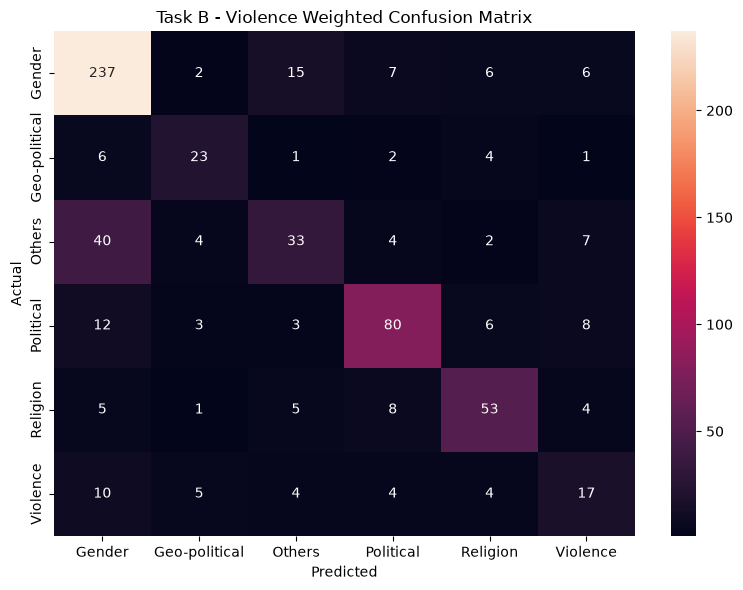

In [71]:
# ============================================================
# TASK B - EVALUATE BEST VIOLENCE-WEIGHTED MODEL
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Recreate the best model
best_class_weights = balanced_weights.copy()
best_class_weights["Violence"] *= 1.75

task_b_violence_weighted = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(2, 5),
        min_df=1,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", LinearSVC(
        C=0.25,
        class_weight=best_class_weights,
        random_state=42
    ))
])

task_b_violence_weighted.fit(
    X_b_train,
    y_b_train
)

y_b_violence_pred = task_b_violence_weighted.predict(X_b_val)

print("=" * 70)
print("BEST VIOLENCE-WEIGHTED MODEL")
print("=" * 70)

print(
    classification_report(
        y_b_val,
        y_b_violence_pred,
        digits=4
    )
)

print("Accuracy :", accuracy_score(y_b_val, y_b_violence_pred))
print(
    "Macro F1 :",
    f1_score(
        y_b_val,
        y_b_violence_pred,
        average="macro"
    )
)

# Confusion matrix
cm = confusion_matrix(
    y_b_val,
    y_b_violence_pred,
    labels=sorted(y_b_val.unique())
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=sorted(y_b_val.unique()),
    yticklabels=sorted(y_b_val.unique())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Task B - Violence Weighted Confusion Matrix")
plt.tight_layout()
plt.show()

In [72]:
# ============================================================
# TASK B - OTHERS -> GENDER ERROR ANALYSIS
# ============================================================

others_gender_errors = error_analysis_b[
    (error_analysis_b["actual"] == "Others") &
    (error_analysis_b["predicted"] == "Gender")
].copy()

print("=" * 70)
print("OTHERS -> GENDER MISCLASSIFICATIONS")
print("=" * 70)

print(f"Total Others samples       : {(y_b_val == 'Others').sum()}")
print(f"Others predicted as Gender : {len(others_gender_errors)}")

display(
    others_gender_errors[
        ["text", "predicted"]
    ].reset_index(drop=True)
)

OTHERS -> GENDER MISCLASSIFICATIONS
Total Others samples       : 90
Others predicted as Gender : 42


,text,predicted
0,nonscence tagondu nivu interview madtidira ......,Gender
1,Harohalli to Bidadi road li odadoke agalla ast...,Gender
2,Pavithra ge Naresh aasti nodi aase ayta... Nar...,Gender
3,Avl ammun Bari kathe chodthavle munde,Gender
4,Bitre avr ammange hodiyo thara kanthidale,Gender
5,Sullu kathe kattu kathe,Gender
6,Nimge bere yaru sigalva thu,Gender
7,Btv avarige bere yaru siglilva evalen Dodd cel...,Gender
8,Mi andre swalpa elrigu aste hurkoltera 😅,Gender
9,arun ge thanks helu ella andidre nin BB ge bar...,Gender


In [73]:
# ============================================================
# TASK B - OTHERS WEIGHTING
# ============================================================

others_multipliers = [1.0, 1.25, 1.5, 1.75, 2.0]

results_others = []

for multiplier in others_multipliers:

    # Start from the original balanced weights
    class_weights = balanced_weights.copy()

    # Keep our successful Violence adjustment
    class_weights["Violence"] *= 1.75

    # Adjust Others
    class_weights["Others"] *= multiplier

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char",
            ngram_range=(2, 5),
            min_df=1,
            sublinear_tf=True,
            max_features=100000
        )),
        ("classifier", LinearSVC(
            C=0.25,
            class_weight=class_weights,
            random_state=42
        ))
    ])

    model.fit(X_b_train, y_b_train)

    pred = model.predict(X_b_val)

    results_others.append({
        "Others Multiplier": multiplier,
        "Accuracy": accuracy_score(y_b_val, pred),
        "Macro F1": f1_score(
            y_b_val,
            pred,
            average="macro"
        )
    })

results_others_df = pd.DataFrame(results_others)

print("=" * 70)
print("OTHERS WEIGHTING + VIOLENCE × 1.75")
print("=" * 70)

display(results_others_df)

OTHERS WEIGHTING + VIOLENCE × 1.75


,Others Multiplier,Accuracy,Macro F1
0,1.00,0.700949,0.615596
1,1.25,0.691456,0.607508
2,1.50,0.693038,0.611594
3,1.75,0.693038,0.616199
4,2.00,0.681962,0.610210


In [74]:
# ============================================================
# TASK B - CURRENT BEST MODEL
# VIOLENCE × 1.75 + OTHERS × 1.75
# ============================================================

best_weights = balanced_weights.copy()

best_weights["Violence"] *= 1.75
best_weights["Others"] *= 1.75

task_b_current_best = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(2, 5),
        min_df=1,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", LinearSVC(
        C=0.25,
        class_weight=best_weights,
        random_state=42
    ))
])

task_b_current_best.fit(X_b_train, y_b_train)

y_b_current_pred = task_b_current_best.predict(X_b_val)

print("=" * 70)
print("CURRENT BEST TASK B MODEL")
print("=" * 70)

print(
    classification_report(
        y_b_val,
        y_b_current_pred,
        digits=4
    )
)

print("Accuracy :", accuracy_score(y_b_val, y_b_current_pred))
print(
    "Macro F1 :",
    f1_score(
        y_b_val,
        y_b_current_pred,
        average="macro"
    )
)

CURRENT BEST TASK B MODEL
               precision    recall  f1-score   support

       Gender     0.7840    0.8242    0.8036       273
Geo-political     0.6000    0.5676    0.5833        37
       Others     0.4592    0.5000    0.4787        90
    Political     0.7879    0.6964    0.7393       112
     Religion     0.7067    0.6974    0.7020        76
     Violence     0.4211    0.3636    0.3902        44

     accuracy                         0.6930       632
    macro avg     0.6265    0.6082    0.6162       632
 weighted avg     0.6931    0.6930    0.6920       632

Accuracy : 0.6930379746835443
Macro F1 : 0.616199219409498


In [75]:
# ============================================================
# TASK B - WEIGHTED WORD + CHARACTER TF-IDF
# ============================================================

from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

# Word features
word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True,
    max_features=50000
)

# Character features
char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=1,
    sublinear_tf=True,
    max_features=100000
)

X_word_train = word_vectorizer.fit_transform(X_b_train)
X_word_val = word_vectorizer.transform(X_b_val)

X_char_train = char_vectorizer.fit_transform(X_b_train)
X_char_val = char_vectorizer.transform(X_b_val)

print("Word features :", X_word_train.shape)
print("Char features :", X_char_train.shape)

# Try several relative weights for word features
word_weights = [0.25, 0.5, 0.75, 1.0]

results_weighted = []

for word_weight in word_weights:

    X_train_combined = hstack([
        X_char_train,
        X_word_train * word_weight
    ])

    X_val_combined = hstack([
        X_char_val,
        X_word_val * word_weight
    ])

    model = LinearSVC(
        C=0.25,
        class_weight=best_weights,
        random_state=42
    )

    model.fit(
        X_train_combined,
        y_b_train
    )

    pred = model.predict(X_val_combined)

    results_weighted.append({
        "Word Weight": word_weight,
        "Accuracy": accuracy_score(y_b_val, pred),
        "Macro F1": f1_score(
            y_b_val,
            pred,
            average="macro"
        )
    })

results_weighted_df = pd.DataFrame(results_weighted)

print("\n" + "=" * 70)
print("WEIGHTED WORD + CHARACTER TF-IDF")
print("=" * 70)

display(results_weighted_df)

Word features : (2527, 39511)
Char features : (2527, 100000)

WEIGHTED WORD + CHARACTER TF-IDF


,Word Weight,Accuracy,Macro F1
0,0.25,0.694620,0.615017
1,0.50,0.697785,0.612538
2,0.75,0.696203,0.601829
3,1.00,0.707278,0.608723


In [76]:
# ============================================================
# TASK B - CHARACTER TF-IDF + LINGUISTIC FEATURES
# ============================================================

import numpy as np
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

def extract_features(texts):
    features = []

    for text in texts:
        length = len(text)
        words = len(text.split())

        features.append([
            length,
            words,
            text.count("!"),
            text.count("?"),
            text.count("."),
            text.count(","),
            text.count("@"),
            text.count("#"),
            text.count(":"),
            text.count("'"),
            sum(c.isupper() for c in text),
            sum(c.isdigit() for c in text),
            sum(not c.isalnum() and not c.isspace() for c in text),
        ])

    return np.array(features, dtype=np.float32)


# ------------------------------------------------------------
# Character TF-IDF
# ------------------------------------------------------------

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=1,
    sublinear_tf=True,
    max_features=100000
)

X_char_train = char_vectorizer.fit_transform(X_b_train)
X_char_val = char_vectorizer.transform(X_b_val)


# ------------------------------------------------------------
# Linguistic features
# ------------------------------------------------------------

X_ling_train = extract_features(X_b_train)
X_ling_val = extract_features(X_b_val)

# Normalize linguistic features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_ling_train = scaler.fit_transform(X_ling_train)
X_ling_val = scaler.transform(X_ling_val)

X_ling_train = csr_matrix(X_ling_train)
X_ling_val = csr_matrix(X_ling_val)


print("Character features :", X_char_train.shape)
print("Linguistic features:", X_ling_train.shape)


# ------------------------------------------------------------
# Try different linguistic feature weights
# ------------------------------------------------------------

ling_weights = [0.1, 0.25, 0.5, 1.0]

results_linguistic = []

for weight in ling_weights:

    X_train_combined = hstack([
        X_char_train,
        X_ling_train * weight
    ])

    X_val_combined = hstack([
        X_char_val,
        X_ling_val * weight
    ])

    model = LinearSVC(
        C=0.25,
        class_weight=best_weights,
        random_state=42
    )

    model.fit(
        X_train_combined,
        y_b_train
    )

    pred = model.predict(X_val_combined)

    results_linguistic.append({
        "Linguistic Weight": weight,
        "Accuracy": accuracy_score(y_b_val, pred),
        "Macro F1": f1_score(
            y_b_val,
            pred,
            average="macro"
        )
    })


results_linguistic_df = pd.DataFrame(results_linguistic)

print("\n" + "=" * 70)
print("CHARACTER TF-IDF + LINGUISTIC FEATURES")
print("=" * 70)

display(results_linguistic_df)

Character features : (2527, 100000)
Linguistic features: (2527, 13)


S:\4.2\bangla\Hastika-ICON2026\.venv\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



CHARACTER TF-IDF + LINGUISTIC FEATURES


S:\4.2\bangla\Hastika-ICON2026\.venv\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,Linguistic Weight,Accuracy,Macro F1
0,0.10,0.689873,0.619519
1,0.25,0.688291,0.616137
2,0.50,0.691456,0.618211
3,1.00,0.686709,0.612531


In [77]:
# ============================================================
# TASK B - BEST LINGUISTIC MODEL
# FIX CONVERGENCE
# ============================================================

X_train_combined = hstack([
    X_char_train,
    X_ling_train * 0.10
])

X_val_combined = hstack([
    X_char_val,
    X_ling_val * 0.10
])

model_ling_best = LinearSVC(
    C=0.25,
    class_weight=best_weights,
    max_iter=10000,
    random_state=42
)

model_ling_best.fit(
    X_train_combined,
    y_b_train
)

pred_ling_best = model_ling_best.predict(X_val_combined)

print("=" * 70)
print("BEST LINGUISTIC MODEL - CONVERGENCE FIXED")
print("=" * 70)

print("Accuracy :", accuracy_score(y_b_val, pred_ling_best))
print("Macro F1 :", f1_score(
    y_b_val,
    pred_ling_best,
    average="macro"
))

BEST LINGUISTIC MODEL - CONVERGENCE FIXED
Accuracy : 0.689873417721519
Macro F1 : 0.6195188205640668


In [78]:
# ============================================================
# TASK B - ERROR ANALYSIS
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix

print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(classification_report(
    y_b_val,
    pred_ling_best,
    digits=4
))

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

labels = sorted(y_b_val.unique())

cm = confusion_matrix(
    y_b_val,
    pred_ling_best,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

display(cm_df)

CLASSIFICATION REPORT
               precision    recall  f1-score   support

       Gender     0.7770    0.8168    0.7964       273
Geo-political     0.6286    0.5946    0.6111        37
       Others     0.4519    0.5222    0.4845        90
    Political     0.7835    0.6786    0.7273       112
     Religion     0.7222    0.6842    0.7027        76
     Violence     0.4324    0.3636    0.3951        44

     accuracy                         0.6899       632
    macro avg     0.6326    0.6100    0.6195       632
 weighted avg     0.6926    0.6899    0.6897       632

CONFUSION MATRIX


,Gender,Geo-political,Others,Political,Religion,Violence
Gender,223,1,31,7,6,5
Geo-political,5,22,4,2,3,1
Others,33,2,47,2,1,5
Political,11,3,10,76,6,6
Religion,4,2,6,8,52,4
Violence,11,5,6,2,4,16


In [79]:
# ============================================================
# TASK B - INSPECT MISCLASSIFIED EXAMPLES
# ============================================================

error_df = pd.DataFrame({
    "text": X_b_val.values,
    "actual": y_b_val.values,
    "predicted": pred_ling_best
})

errors = error_df[
    error_df["actual"] != error_df["predicted"]
].copy()

print("Total validation samples :", len(error_df))
print("Total misclassified      :", len(errors))
print("Error rate               :", len(errors) / len(error_df))

print("\n" + "=" * 70)
print("VIOLENCE MISCLASSIFICATIONS")
print("=" * 70)

violence_errors = errors[
    errors["actual"] == "Violence"
]

display(violence_errors.to_string(index=False))


print("\n" + "=" * 70)
print("OTHERS MISCLASSIFICATIONS")
print("=" * 70)

others_errors = errors[
    errors["actual"] == "Others"
]

display(others_errors.to_string(index=False))

Total validation samples : 632
Total misclassified      : 196
Error rate               : 0.310126582278481

VIOLENCE MISCLASSIFICATIONS


'                                                                                                                                                                                                                                                                                                                                             text   actual     predicted\n                                                                                                                                                                                                                                                                                                Huchcha ee tara galabhe ella ebbisi en sadhastiya Violence        Gender\n                                                                                                                                                                                                                    Adikke vayasadamele buddi kadime aagutte andu nale Dina nimgu s


OTHERS MISCLASSIFICATIONS


'                                                                                                                                                                                                                                                                                                                                       text actual     predicted\n                                                                                                                                                                                                                    Astorolagagale, kala meeriruttade. Neevu sayuva varegu kanneridutta koragi sayutteeri Jai BJP, Jai Modi, Jai Bhajarangi Others     Political\n                                                                                                                                                                                                                                                                            Harohalli to Bidadi roa

In [80]:
# ============================================================
# TASK B - CATEGORY-SPECIFIC WORD ANALYSIS
# ============================================================

from collections import Counter
import re

print("=" * 70)
print("MOST COMMON WORDS BY CATEGORY")
print("=" * 70)

for category in sorted(y_b_train.unique()):

    texts = X_b_train[y_b_train == category]

    words = []

    for text in texts:
        # Keep Romanized Kannada, English, Kannada, numbers, etc.
        tokens = re.findall(r"\S+", text.lower())
        words.extend(tokens)

    counter = Counter(words)

    print(f"\n{'=' * 20} {category} {'=' * 20}")

    for word, count in counter.most_common(20):
        print(f"{word:25s} {count}")

MOST COMMON WORDS BY CATEGORY

==================== Gender ====================
nin                       134
ge                        106
antha                     90
dagar                     82
sonu                      75
sule                      71
na                        65
nim                       64
thu                       64
anta                      58
amma                      58
e                         56
nan                       56
ninu                      54
munde                     51
ninge                     50
ee                        47
maga                      44
illa                      43
video                     42

==================== Geo-political ====================
pakistan                  29
kannada                   25
ge                        20
ee                        16
nam                       15
hogi                      13
ella                      12
e                         12
alli                      12
namma               

In [81]:
# ============================================================
# TASK B - CHARACTER + WORD (1,3) + LINGUISTIC FEATURES
# ============================================================

from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

# ------------------------------------------------------------
# Word TF-IDF
# ------------------------------------------------------------

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 3),
    min_df=1,
    sublinear_tf=True,
    max_features=75000
)

X_word_train = word_vectorizer.fit_transform(X_b_train)
X_word_val = word_vectorizer.transform(X_b_val)

print("Word features      :", X_word_train.shape)
print("Character features :", X_char_train.shape)
print("Linguistic features:", X_ling_train.shape)


# ------------------------------------------------------------
# Combine all features
# ------------------------------------------------------------

X_train_combined = hstack([
    X_char_train,
    X_word_train * 0.10,
    X_ling_train * 0.10
])

X_val_combined = hstack([
    X_char_val,
    X_word_val * 0.10,
    X_ling_val * 0.10
])


# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

model_word_char_ling = LinearSVC(
    C=0.25,
    class_weight=best_weights,
    max_iter=10000,
    random_state=42
)

model_word_char_ling.fit(
    X_train_combined,
    y_b_train
)

pred_word_char_ling = model_word_char_ling.predict(
    X_val_combined
)


# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_b_val,
    pred_word_char_ling
)

macro_f1 = f1_score(
    y_b_val,
    pred_word_char_ling,
    average="macro"
)

print("\n" + "=" * 70)
print("CHARACTER + WORD (1,3) + LINGUISTIC FEATURES")
print("=" * 70)

print("Accuracy :", accuracy)
print("Macro F1 :", macro_f1)

print("\nImprovement over current best:")
print("Previous Macro F1 : 0.619519")
print("Current  Macro F1 :", macro_f1)
print("Difference        :", macro_f1 - 0.619519)

Word features      : (2527, 66020)
Character features : (2527, 100000)
Linguistic features: (2527, 13)

CHARACTER + WORD (1,3) + LINGUISTIC FEATURES
Accuracy : 0.689873417721519
Macro F1 : 0.6199277324277325

Improvement over current best:
Previous Macro F1 : 0.619519
Current  Macro F1 : 0.6199277324277325
Difference        : 0.0004087324277324278


In [82]:
# Current Task B benchmark

TASK_B_BEST_F1 = 0.6199277324277325

print("Task B benchmark Macro-F1:", TASK_B_BEST_F1)

Task B benchmark Macro-F1: 0.6199277324277325


In [83]:
# ============================================================
# TASK B - DECISION SCORE ANALYSIS
# ============================================================

from sklearn.metrics import classification_report
import numpy as np
import pandas as pd

# Decision scores
decision_scores = model_word_char_ling.decision_function(
    X_val_combined
)

print("Decision score shape:", decision_scores.shape)

# ------------------------------------------------------------
# Show confidence distribution
# ------------------------------------------------------------

max_scores = np.max(decision_scores, axis=1)

confidence_df = pd.DataFrame({
    "actual": y_b_val.values,
    "predicted": pred_word_char_ling,
    "confidence": max_scores
})

print("\n" + "=" * 70)
print("CONFIDENCE STATISTICS")
print("=" * 70)

display(
    confidence_df.groupby("actual")["confidence"]
    .agg(["count", "mean", "median", "min", "max"])
)


# ------------------------------------------------------------
# Misclassified samples with LOW confidence
# ------------------------------------------------------------

errors = confidence_df[
    confidence_df["actual"] != confidence_df["predicted"]
].copy()

print("\n" + "=" * 70)
print("LOW-CONFIDENCE ERRORS")
print("=" * 70)

display(
    errors.sort_values("confidence")
    .head(30)
)

Decision score shape: (632, 6)

CONFIDENCE STATISTICS


,count,mean,median,min,max
actual,,,,,
Gender,273,-0.047040,-0.097238,-0.496701,1.100929
Geo-political,37,-0.130363,-0.255643,-0.542697,0.644880
Others,90,-0.124332,-0.206027,-0.505057,0.980837
Political,112,0.010739,-0.104396,-0.514795,1.402088
Religion,76,0.078773,-0.061293,-0.460610,1.204429
Violence,44,-0.119262,-0.231669,-0.544194,0.775578



LOW-CONFIDENCE ERRORS


,actual,predicted,confidence
321,Political,Gender,-0.514795
318,Others,Gender,-0.505057
41,Gender,Others,-0.496701
362,Gender,Others,-0.489081
340,Others,Violence,-0.478893
591,Gender,Political,-0.477677
15,Violence,Gender,-0.473330
242,Others,Political,-0.471737
325,Others,Geo-political,-0.468867
9,Political,Violence,-0.467386


In [85]:
# ============================================================
# TASK B - LOGISTIC REGRESSION
# Character + Word + Linguistic Features
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

logreg_model = LogisticRegression(
    C=1.0,
    class_weight=best_weights,
    max_iter=3000,
    solver="lbfgs",
    random_state=42
)

logreg_model.fit(
    X_train_combined,
    y_b_train
)

pred_logreg = logreg_model.predict(
    X_val_combined
)

accuracy_logreg = accuracy_score(
    y_b_val,
    pred_logreg
)

macro_f1_logreg = f1_score(
    y_b_val,
    pred_logreg,
    average="macro"
)

print("=" * 70)
print("LOGISTIC REGRESSION")
print("=" * 70)

print("Accuracy :", accuracy_logreg)
print("Macro F1 :", macro_f1_logreg)

print("\nComparison:")
print("LinearSVC Macro F1 :", 0.6199277)
print("LogReg   Macro F1 :", macro_f1_logreg)
print("Difference        :", macro_f1_logreg - 0.6199277)

LOGISTIC REGRESSION
Accuracy : 0.5727848101265823
Macro F1 : 0.5522697749482821

Comparison:
LinearSVC Macro F1 : 0.6199277
LogReg   Macro F1 : 0.5522697749482821
Difference        : -0.06765792505171786


In [86]:
# ============================================================
# TASK B - LINEAR SVM ENSEMBLE
# ============================================================

import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# ------------------------------------------------------------
# Get decision scores from both models
# ------------------------------------------------------------

scores_char = task_b_current_best.decision_function(
    X_char_val
)

scores_full = model_word_char_ling.decision_function(
    X_val_combined
)

print("Char score shape :", scores_char.shape)
print("Full score shape :", scores_full.shape)


# ------------------------------------------------------------
# Try different ensemble weights
# ------------------------------------------------------------

ensemble_weights = [0.25, 0.5, 0.75]

ensemble_results = []

for w in ensemble_weights:

    combined_scores = (
        w * scores_full
        + (1 - w) * scores_char
    )

    pred_ensemble = model_word_char_ling.classes_[
        np.argmax(combined_scores, axis=1)
    ]

    acc = accuracy_score(
        y_b_val,
        pred_ensemble
    )

    f1 = f1_score(
        y_b_val,
        pred_ensemble,
        average="macro"
    )

    ensemble_results.append({
        "Full Model Weight": w,
        "Char Model Weight": 1 - w,
        "Accuracy": acc,
        "Macro F1": f1
    })


ensemble_results_df = pd.DataFrame(
    ensemble_results
)

print("\n" + "=" * 70)
print("LINEAR SVM ENSEMBLE")
print("=" * 70)

display(ensemble_results_df)

AttributeError: 'csr_matrix' object has no attribute 'lower'

In [87]:
# ============================================================
# TASK B - LINEAR SVM ENSEMBLE
# CORRECTED VERSION
# ============================================================

import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# ------------------------------------------------------------
# Get decision scores from the existing models
# ------------------------------------------------------------

# Character-only model
char_svm = task_b_current_best.named_steps["classifier"]

scores_char = char_svm.decision_function(
    X_char_val
)

# Full model: Character + Word + Linguistic
scores_full = model_word_char_ling.decision_function(
    X_val_combined
)

print("Char score shape :", scores_char.shape)
print("Full score shape :", scores_full.shape)


# ------------------------------------------------------------
# Try different ensemble weights
# ------------------------------------------------------------

ensemble_weights = [0.25, 0.5, 0.75]

ensemble_results = []

for w in ensemble_weights:

    combined_scores = (
        w * scores_full
        + (1 - w) * scores_char
    )

    pred_ensemble = model_word_char_ling.classes_[
        np.argmax(combined_scores, axis=1)
    ]

    acc = accuracy_score(
        y_b_val,
        pred_ensemble
    )

    f1 = f1_score(
        y_b_val,
        pred_ensemble,
        average="macro"
    )

    ensemble_results.append({
        "Full Model Weight": w,
        "Char Model Weight": 1 - w,
        "Accuracy": acc,
        "Macro F1": f1
    })


ensemble_results_df = pd.DataFrame(
    ensemble_results
)

print("\n" + "=" * 70)
print("LINEAR SVM ENSEMBLE")
print("=" * 70)

display(ensemble_results_df)

Char score shape : (632, 6)
Full score shape : (632, 6)

LINEAR SVM ENSEMBLE


,Full Model Weight,Char Model Weight,Accuracy,Macro F1
0,0.25,0.75,0.691456,0.616486
1,0.50,0.50,0.691456,0.619224
2,0.75,0.25,0.693038,0.621207


In [88]:
# ============================================================
# TASK B - BEST ENSEMBLE EVALUATION
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix

# Best ensemble weight
best_w = 0.75

combined_scores_best = (
    best_w * scores_full
    + (1 - best_w) * scores_char
)

pred_ensemble_best = model_word_char_ling.classes_[
    np.argmax(combined_scores_best, axis=1)
]

print("=" * 70)
print("BEST ENSEMBLE - CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_b_val,
        pred_ensemble_best,
        digits=4
    )
)

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

labels = sorted(y_b_val.unique())

cm_ensemble = confusion_matrix(
    y_b_val,
    pred_ensemble_best,
    labels=labels
)

cm_ensemble_df = pd.DataFrame(
    cm_ensemble,
    index=labels,
    columns=labels
)

display(cm_ensemble_df)

BEST ENSEMBLE - CLASSIFICATION REPORT
               precision    recall  f1-score   support

       Gender     0.7785    0.8242    0.8007       273
Geo-political     0.6286    0.5946    0.6111        37
       Others     0.4554    0.5111    0.4817        90
    Political     0.7835    0.6786    0.7273       112
     Religion     0.7260    0.6974    0.7114        76
     Violence     0.4324    0.3636    0.3951        44

     accuracy                         0.6930       632
    macro avg     0.6341    0.6116    0.6212       632
 weighted avg     0.6942    0.6930    0.6922       632

CONFUSION MATRIX


,Gender,Geo-political,Others,Political,Religion,Violence
Gender,225,1,30,7,6,4
Geo-political,5,22,4,2,3,1
Others,33,3,46,2,1,5
Political,11,3,9,76,6,7
Religion,4,1,6,8,53,4
Violence,11,5,6,2,4,16


In [89]:
# ============================================================
# TASK B - VIOLENCE DECISION SCORE BOOST
# ============================================================

violence_index = list(model_word_char_ling.classes_).index("Violence")

violence_boosts = [0.00, 0.02, 0.05, 0.10, 0.15, 0.20]

violence_results = []

for boost in violence_boosts:

    adjusted_scores = combined_scores_best.copy()

    adjusted_scores[:, violence_index] += boost

    pred = model_word_char_ling.classes_[
        np.argmax(adjusted_scores, axis=1)
    ]

    acc = accuracy_score(y_b_val, pred)
    f1 = f1_score(y_b_val, pred, average="macro")

    violence_results.append({
        "Violence Boost": boost,
        "Accuracy": acc,
        "Macro F1": f1
    })

violence_results_df = pd.DataFrame(violence_results)

print("=" * 70)
print("VIOLENCE DECISION SCORE BOOST")
print("=" * 70)

display(violence_results_df)

VIOLENCE DECISION SCORE BOOST


,Violence Boost,Accuracy,Macro F1
0,0.00,0.693038,0.621207
1,0.02,0.691456,0.620690
2,0.05,0.685127,0.611353
3,0.10,0.681962,0.608461
4,0.15,0.678797,0.610838
5,0.20,0.670886,0.603522


In [90]:
# ============================================================
# TASK B - MULTINOMIAL NAIVE BAYES
# ============================================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

task_b_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(2, 5),
        min_df=1,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", MultinomialNB(alpha=0.1))
])

task_b_nb.fit(X_b_train, y_b_train)

pred_nb = task_b_nb.predict(X_b_val)

acc_nb = accuracy_score(y_b_val, pred_nb)
f1_nb = f1_score(y_b_val, pred_nb, average="macro")

print("=" * 70)
print("TASK B - MULTINOMIAL NAIVE BAYES")
print("=" * 70)

print(f"Accuracy : {acc_nb:.6f}")
print(f"Macro F1 : {f1_nb:.6f}")

print()
print(classification_report(
    y_b_val,
    pred_nb,
    digits=4
))

TASK B - MULTINOMIAL NAIVE BAYES
Accuracy : 0.590190
Macro F1 : 0.356637

               precision    recall  f1-score   support

       Gender     0.5361    0.9780    0.6926       273
Geo-political     0.0000    0.0000    0.0000        37
       Others     0.8333    0.1111    0.1961        90
    Political     0.7975    0.5625    0.6597       112
     Religion     0.7805    0.4211    0.5470        76
     Violence     1.0000    0.0227    0.0444        44

     accuracy                         0.5902       632
    macro avg     0.6579    0.3492    0.3566       632
 weighted avg     0.6551    0.5902    0.5129       632



In [91]:
# ============================================================
# TASK B - WORD TF-IDF (1,3) + LINEAR SVM
# ============================================================

task_b_word_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 3),
        min_df=1,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", LinearSVC(
        C=0.25,
        class_weight=best_weights,
        max_iter=10000,
        random_state=42
    ))
])

task_b_word_svm.fit(X_b_train, y_b_train)

pred_word_svm = task_b_word_svm.predict(X_b_val)

acc_word_svm = accuracy_score(y_b_val, pred_word_svm)
f1_word_svm = f1_score(y_b_val, pred_word_svm, average="macro")

print("=" * 70)
print("TASK B - WORD TF-IDF + LINEAR SVM")
print("=" * 70)

print(f"Accuracy : {acc_word_svm:.6f}")
print(f"Macro F1 : {f1_word_svm:.6f}")

print()
print(classification_report(
    y_b_val,
    pred_word_svm,
    digits=4
))

TASK B - WORD TF-IDF + LINEAR SVM
Accuracy : 0.661392
Macro F1 : 0.562417

               precision    recall  f1-score   support

       Gender     0.7323    0.8315    0.7787       273
Geo-political     0.5806    0.4865    0.5294        37
       Others     0.4112    0.4889    0.4467        90
    Political     0.8046    0.6250    0.7035       112
     Religion     0.6375    0.6711    0.6538        76
     Violence     0.4706    0.1818    0.2623        44

     accuracy                         0.6614       632
    macro avg     0.6061    0.5475    0.5624       632
 weighted avg     0.6609    0.6614    0.6526       632



In [92]:
# ============================================================
# TASK B - CHARACTER WB TF-IDF + LINEAR SVM
# ============================================================

task_b_char_wb = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(2, 5),
        min_df=1,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", LinearSVC(
        C=0.25,
        class_weight=best_weights,
        max_iter=10000,
        random_state=42
    ))
])

task_b_char_wb.fit(X_b_train, y_b_train)

pred_char_wb = task_b_char_wb.predict(X_b_val)

acc_char_wb = accuracy_score(y_b_val, pred_char_wb)
f1_char_wb = f1_score(y_b_val, pred_char_wb, average="macro")

print("=" * 70)
print("TASK B - CHARACTER WB TF-IDF + LINEAR SVM")
print("=" * 70)

print(f"Accuracy : {acc_char_wb:.6f}")
print(f"Macro F1 : {f1_char_wb:.6f}")

print()
print(classification_report(
    y_b_val,
    pred_char_wb,
    digits=4
))

TASK B - CHARACTER WB TF-IDF + LINEAR SVM
Accuracy : 0.704114
Macro F1 : 0.633137

               precision    recall  f1-score   support

       Gender     0.8066    0.8095    0.8080       273
Geo-political     0.6316    0.6486    0.6400        37
       Others     0.4495    0.5444    0.4925        90
    Political     0.8469    0.7411    0.7905       112
     Religion     0.7067    0.6974    0.7020        76
     Violence     0.3947    0.3409    0.3659        44

     accuracy                         0.7041       632
    macro avg     0.6393    0.6303    0.6331       632
 weighted avg     0.7120    0.7041    0.7066       632



In [93]:
# ============================================================
# TASK B - CHAR_WB N-GRAM TUNING
# ============================================================

char_wb_ranges = [
    (2, 4),
    (2, 5),
    (2, 6),
    (3, 5),
    (3, 6),
    (3, 7)
]

char_wb_results = []

for ngram_range in char_wb_ranges:

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=ngram_range,
            min_df=1,
            sublinear_tf=True,
            max_features=100000
        )),
        ("classifier", LinearSVC(
            C=0.25,
            class_weight=best_weights,
            max_iter=10000,
            random_state=42
        ))
    ])

    model.fit(X_b_train, y_b_train)

    pred = model.predict(X_b_val)

    acc = accuracy_score(y_b_val, pred)
    f1 = f1_score(y_b_val, pred, average="macro")

    char_wb_results.append({
        "N-gram Range": str(ngram_range),
        "Accuracy": acc,
        "Macro F1": f1
    })

char_wb_results_df = pd.DataFrame(char_wb_results)

print("=" * 70)
print("CHAR_WB N-GRAM TUNING")
print("=" * 70)

display(
    char_wb_results_df.sort_values(
        "Macro F1",
        ascending=False
    ).reset_index(drop=True)
)

CHAR_WB N-GRAM TUNING


,N-gram Range,Accuracy,Macro F1
0,"(2, 5)",0.704114,0.633137
1,"(2, 6)",0.704114,0.632217
2,"(3, 5)",0.697785,0.631610
3,"(3, 6)",0.689873,0.619461
4,"(3, 7)",0.685127,0.615251
5,"(2, 4)",0.686709,0.608143


In [94]:
# ============================================================
# TASK B - CHAR_WB SVM C TUNING
# ============================================================

C_values = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.50,
    0.75
]

C_results = []

for C_value in C_values:

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(2, 5),
            min_df=1,
            sublinear_tf=True,
            max_features=100000
        )),
        ("classifier", LinearSVC(
            C=C_value,
            class_weight=best_weights,
            max_iter=10000,
            random_state=42
        ))
    ])

    model.fit(X_b_train, y_b_train)

    pred = model.predict(X_b_val)

    acc = accuracy_score(y_b_val, pred)
    f1 = f1_score(y_b_val, pred, average="macro")

    C_results.append({
        "C": C_value,
        "Accuracy": acc,
        "Macro F1": f1
    })

C_results_df = pd.DataFrame(C_results)

print("=" * 70)
print("CHAR_WB SVM - C TUNING")
print("=" * 70)

display(
    C_results_df.sort_values(
        "Macro F1",
        ascending=False
    ).reset_index(drop=True)
)

CHAR_WB SVM - C TUNING


,C,Accuracy,Macro F1
0,0.25,0.704114,0.633137
1,0.30,0.704114,0.629704
2,0.20,0.696203,0.624122
3,0.50,0.699367,0.620932
4,0.75,0.694620,0.610455
5,0.15,0.677215,0.605700
6,0.10,0.666139,0.604486
7,0.05,0.639241,0.586935


In [95]:
# ============================================================
# TASK B - CHAR_WB CLASS WEIGHT TUNING
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

classes = np.array(sorted(y_b_train.unique()))

balanced_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_b_train
)

char_wb_balanced_weights = dict(
    zip(classes, balanced_values)
)

print("Balanced weights:")
for cls, weight in char_wb_balanced_weights.items():
    print(f"{cls:15s}: {weight:.4f}")

# Test Violence multipliers
violence_multipliers = [1.0, 1.25, 1.5, 1.75, 2.0]

weight_results = []

for multiplier in violence_multipliers:

    weights = char_wb_balanced_weights.copy()
    weights["Violence"] *= multiplier

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(2, 5),
            min_df=1,
            sublinear_tf=True,
            max_features=100000
        )),
        ("classifier", LinearSVC(
            C=0.25,
            class_weight=weights,
            max_iter=10000,
            random_state=42
        ))
    ])

    model.fit(X_b_train, y_b_train)

    pred = model.predict(X_b_val)

    acc = accuracy_score(y_b_val, pred)
    f1 = f1_score(y_b_val, pred, average="macro")

    weight_results.append({
        "Violence Multiplier": multiplier,
        "Accuracy": acc,
        "Macro F1": f1
    })

weight_results_df = pd.DataFrame(weight_results)

print()
print("=" * 70)
print("CHAR_WB - VIOLENCE WEIGHT TUNING")
print("=" * 70)

display(
    weight_results_df.sort_values(
        "Macro F1",
        ascending=False
    ).reset_index(drop=True)
)

Balanced weights:
Gender         : 0.3867
Geo-political  : 2.8266
Others         : 1.1732
Political      : 0.9422
Religion       : 1.3764
Violence       : 2.3795

CHAR_WB - VIOLENCE WEIGHT TUNING


,Violence Multiplier,Accuracy,Macro F1
0,1.00,0.718354,0.633277
1,1.25,0.715190,0.629304
2,1.50,0.713608,0.627119
3,1.75,0.710443,0.622279
4,2.00,0.710443,0.622279


In [96]:
# ============================================================
# TASK B - BEST CHAR_WB BALANCED MODEL
# ============================================================

task_b_char_wb_best = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(2, 5),
        min_df=1,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", LinearSVC(
        C=0.25,
        class_weight="balanced",
        max_iter=10000,
        random_state=42
    ))
])

task_b_char_wb_best.fit(X_b_train, y_b_train)

pred_char_wb_best = task_b_char_wb_best.predict(X_b_val)

acc_best = accuracy_score(y_b_val, pred_char_wb_best)
f1_best = f1_score(y_b_val, pred_char_wb_best, average="macro")

print("=" * 70)
print("CURRENT TASK B CHAMPION")
print("=" * 70)

print(f"Accuracy : {acc_best:.6f}")
print(f"Macro F1 : {f1_best:.6f}")

print()
print(classification_report(
    y_b_val,
    pred_char_wb_best,
    digits=4
))

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

labels = sorted(y_b_val.unique())

cm_best = confusion_matrix(
    y_b_val,
    pred_char_wb_best,
    labels=labels
)

display(pd.DataFrame(
    cm_best,
    index=labels,
    columns=labels
))

CURRENT TASK B CHAMPION
Accuracy : 0.718354
Macro F1 : 0.633277

               precision    recall  f1-score   support

       Gender     0.7710    0.8755    0.8199       273
Geo-political     0.5952    0.6757    0.6329        37
       Others     0.5522    0.4111    0.4713        90
    Political     0.8095    0.7589    0.7834       112
     Religion     0.6974    0.6974    0.6974        76
     Violence     0.4688    0.3409    0.3947        44

     accuracy                         0.7184       632
    macro avg     0.6490    0.6266    0.6333       632
 weighted avg     0.7065    0.7184    0.7085       632

CONFUSION MATRIX


,Gender,Geo-political,Others,Political,Religion,Violence
Gender,239,3,17,6,6,2
Geo-political,4,25,1,2,4,1
Others,39,4,37,3,2,5
Political,8,2,6,85,6,5
Religion,7,3,3,6,53,4
Violence,13,5,3,3,5,15


In [97]:
# ============================================================
# TASK B - CHAR_WB OTHERS WEIGHT TUNING
# ============================================================

others_multipliers = [
    1.00,
    1.10,
    1.20,
    1.30,
    1.40,
    1.50
]

others_results = []

# Base balanced weights
classes = np.array(sorted(y_b_train.unique()))

balanced_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_b_train
)

balanced_weights_char_wb = dict(
    zip(classes, balanced_values)
)

for multiplier in others_multipliers:

    weights = balanced_weights_char_wb.copy()
    weights["Others"] *= multiplier

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(2, 5),
            min_df=1,
            sublinear_tf=True,
            max_features=100000
        )),
        ("classifier", LinearSVC(
            C=0.25,
            class_weight=weights,
            max_iter=10000,
            random_state=42
        ))
    ])

    model.fit(X_b_train, y_b_train)

    pred = model.predict(X_b_val)

    acc = accuracy_score(y_b_val, pred)
    f1 = f1_score(y_b_val, pred, average="macro")

    others_results.append({
        "Others Multiplier": multiplier,
        "Accuracy": acc,
        "Macro F1": f1
    })

others_results_df = pd.DataFrame(others_results)

print("=" * 70)
print("CHAR_WB - OTHERS WEIGHT TUNING")
print("=" * 70)

display(
    others_results_df.sort_values(
        "Macro F1",
        ascending=False
    ).reset_index(drop=True)
)

CHAR_WB - OTHERS WEIGHT TUNING


,Others Multiplier,Accuracy,Macro F1
0,1.3,0.723101,0.644205
1,1.5,0.716772,0.640524
2,1.4,0.718354,0.640431
3,1.2,0.718354,0.639419
4,1.1,0.719937,0.636786
5,1.0,0.718354,0.633277


In [98]:
# ============================================================
# TASK B - FINE-TUNE OTHERS WEIGHT
# ============================================================

fine_multipliers = [
    1.25,
    1.275,
    1.30,
    1.325,
    1.35
]

fine_results = []

for multiplier in fine_multipliers:

    weights = balanced_weights_char_wb.copy()
    weights["Others"] *= multiplier

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(2, 5),
            min_df=1,
            sublinear_tf=True,
            max_features=100000
        )),
        ("classifier", LinearSVC(
            C=0.25,
            class_weight=weights,
            max_iter=10000,
            random_state=42
        ))
    ])

    model.fit(X_b_train, y_b_train)

    pred = model.predict(X_b_val)

    acc = accuracy_score(y_b_val, pred)
    f1 = f1_score(y_b_val, pred, average="macro")

    fine_results.append({
        "Others Multiplier": multiplier,
        "Accuracy": acc,
        "Macro F1": f1
    })

fine_results_df = pd.DataFrame(fine_results)

print("=" * 70)
print("CHAR_WB - FINE OTHERS WEIGHT TUNING")
print("=" * 70)

display(
    fine_results_df.sort_values(
        "Macro F1",
        ascending=False
    ).reset_index(drop=True)
)

CHAR_WB - FINE OTHERS WEIGHT TUNING


,Others Multiplier,Accuracy,Macro F1
0,1.300,0.723101,0.644205
1,1.325,0.721519,0.643383
2,1.350,0.719937,0.642565
3,1.275,0.719937,0.640622
4,1.250,0.718354,0.639182


In [99]:
# ============================================================
# TASK B - FINAL REPORT FOR CURRENT CHAMPION
# ============================================================

final_weights = balanced_weights_char_wb.copy()
final_weights["Others"] *= 1.30

task_b_champion = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(2, 5),
        min_df=1,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", LinearSVC(
        C=0.25,
        class_weight=final_weights,
        max_iter=10000,
        random_state=42
    ))
])

task_b_champion.fit(X_b_train, y_b_train)

y_b_pred = task_b_champion.predict(X_b_val)

print("=" * 70)
print("TASK B - CURRENT CHAMPION")
print("=" * 70)

print(f"Accuracy : {accuracy_score(y_b_val, y_b_pred):.4f}")
print(f"Macro-F1 : {f1_score(y_b_val, y_b_pred, average='macro'):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_b_val,
        y_b_pred,
        digits=4
    )
)

print("\nConfusion Matrix:")
cm = confusion_matrix(
    y_b_val,
    y_b_pred,
    labels=task_b_champion.classes_
)

cm_df = pd.DataFrame(
    cm,
    index=task_b_champion.classes_,
    columns=task_b_champion.classes_
)

display(cm_df)

TASK B - CURRENT CHAMPION
Accuracy : 0.7231
Macro-F1 : 0.6442

Classification Report:
               precision    recall  f1-score   support

       Gender     0.7986    0.8571    0.8269       273
Geo-political     0.6098    0.6757    0.6410        37
       Others     0.5169    0.5111    0.5140        90
    Political     0.8155    0.7500    0.7814       112
     Religion     0.7067    0.6974    0.7020        76
     Violence     0.4839    0.3409    0.4000        44

     accuracy                         0.7231       632
    macro avg     0.6552    0.6387    0.6442       632
 weighted avg     0.7175    0.7231    0.7186       632


Confusion Matrix:


,Gender,Geo-political,Others,Political,Religion,Violence
Gender,234,3,22,6,6,2
Geo-political,3,25,3,2,3,1
Others,32,3,46,2,2,5
Political,7,2,9,84,6,4
Religion,5,3,5,6,53,4
Violence,12,5,4,3,5,15


In [100]:
# ============================================================
# TASK B - CHAR_WB N-GRAM FINE TUNING
# ============================================================

ngram_configs = [
    (2, 4),
    (2, 5),
    (2, 6),
    (2, 7),
    (3, 5),
    (3, 6),
]

ngram_results = []

for ngram_range in ngram_configs:

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=ngram_range,
            min_df=1,
            sublinear_tf=True,
            max_features=100000
        )),
        ("classifier", LinearSVC(
            C=0.25,
            class_weight=final_weights,
            max_iter=10000,
            random_state=42
        ))
    ])

    model.fit(X_b_train, y_b_train)

    pred = model.predict(X_b_val)

    acc = accuracy_score(y_b_val, pred)
    f1 = f1_score(y_b_val, pred, average="macro")

    ngram_results.append({
        "N-gram Range": str(ngram_range),
        "Accuracy": acc,
        "Macro F1": f1
    })

ngram_results_df = pd.DataFrame(ngram_results)

print("=" * 70)
print("TASK B - CHAR_WB N-GRAM FINE TUNING")
print("=" * 70)

display(
    ngram_results_df.sort_values(
        "Macro F1",
        ascending=False
    ).reset_index(drop=True)
)

TASK B - CHAR_WB N-GRAM FINE TUNING


,N-gram Range,Accuracy,Macro F1
0,"(2, 5)",0.723101,0.644205
1,"(2, 6)",0.716772,0.634842
2,"(3, 5)",0.710443,0.632800
3,"(2, 7)",0.715190,0.630994
4,"(3, 6)",0.705696,0.625114
5,"(2, 4)",0.705696,0.622258


In [101]:
# ============================================================
# TASK B - CHAR_WB + WORD SVM ENSEMBLE
# ============================================================

# ------------------------------------------------------------
# 1. Train current CHAR_WB model
# ------------------------------------------------------------

char_wb_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(2, 5),
        min_df=1,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", LinearSVC(
        C=0.25,
        class_weight=final_weights,
        max_iter=10000,
        random_state=42
    ))
])

char_wb_model.fit(X_b_train, y_b_train)

scores_char_wb = char_wb_model.decision_function(X_b_val)


# ------------------------------------------------------------
# 2. Train WORD model
# ------------------------------------------------------------

word_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 3),
        min_df=1,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", LinearSVC(
        C=0.25,
        class_weight=final_weights,
        max_iter=10000,
        random_state=42
    ))
])

word_model.fit(X_b_train, y_b_train)

scores_word = word_model.decision_function(X_b_val)


# ------------------------------------------------------------
# 3. Ensemble
# ------------------------------------------------------------

ensemble_results = []

for char_weight in [
    0.50,
    0.60,
    0.70,
    0.75,
    0.80,
    0.85,
    0.90,
    1.00
]:

    word_weight = 1.0 - char_weight

    combined_scores = (
        char_weight * scores_char_wb
        + word_weight * scores_word
    )

    pred = char_wb_model.classes_[
        np.argmax(combined_scores, axis=1)
    ]

    acc = accuracy_score(y_b_val, pred)
    f1 = f1_score(y_b_val, pred, average="macro")

    ensemble_results.append({
        "Char-WB Weight": char_weight,
        "Word Weight": word_weight,
        "Accuracy": acc,
        "Macro F1": f1
    })


ensemble_results_df = pd.DataFrame(ensemble_results)

print("=" * 70)
print("TASK B - CHAR_WB + WORD SVM ENSEMBLE")
print("=" * 70)

display(
    ensemble_results_df.sort_values(
        "Macro F1",
        ascending=False
    ).reset_index(drop=True)
)

TASK B - CHAR_WB + WORD SVM ENSEMBLE


,Char-WB Weight,Word Weight,Accuracy,Macro F1
0,0.85,0.15,0.724684,0.645536
1,1.00,0.00,0.723101,0.644205
2,0.90,0.10,0.718354,0.640669
3,0.80,0.20,0.715190,0.632692
4,0.75,0.25,0.713608,0.629057
5,0.70,0.30,0.710443,0.625444
6,0.60,0.40,0.708861,0.619199
7,0.50,0.50,0.705696,0.603813


In [102]:
# ============================================================
# TASK B - FINE-TUNE CHAR-WB + WORD ENSEMBLE
# ============================================================

ensemble_weights = [
    0.80,
    0.825,
    0.85,
    0.875,
    0.90,
    0.925
]

fine_ensemble_results = []

for char_weight in ensemble_weights:

    word_weight = 1.0 - char_weight

    combined_scores = (
        char_weight * scores_char_wb
        + word_weight * scores_word
    )

    pred = char_wb_model.classes_[
        np.argmax(combined_scores, axis=1)
    ]

    acc = accuracy_score(y_b_val, pred)
    f1 = f1_score(y_b_val, pred, average="macro")

    fine_ensemble_results.append({
        "Char-WB Weight": char_weight,
        "Word Weight": word_weight,
        "Accuracy": acc,
        "Macro F1": f1
    })

fine_ensemble_results_df = pd.DataFrame(fine_ensemble_results)

print("=" * 70)
print("TASK B - FINE CHAR-WB + WORD ENSEMBLE")
print("=" * 70)

display(
    fine_ensemble_results_df.sort_values(
        "Macro F1",
        ascending=False
    ).reset_index(drop=True)
)

TASK B - FINE CHAR-WB + WORD ENSEMBLE


,Char-WB Weight,Word Weight,Accuracy,Macro F1
0,0.850,0.150,0.724684,0.645536
1,0.875,0.125,0.724684,0.644984
2,0.900,0.100,0.718354,0.640669
3,0.825,0.175,0.721519,0.639671
4,0.925,0.075,0.718354,0.638714
5,0.800,0.200,0.715190,0.632692


In [103]:
# ============================================================
# TASK B - ENSEMBLE CLASSIFICATION REPORT
# ============================================================

best_ensemble_scores = (
    0.85 * scores_char_wb
    + 0.15 * scores_word
)

best_ensemble_pred = char_wb_model.classes_[
    np.argmax(best_ensemble_scores, axis=1)
]

print("=" * 70)
print("TASK B - BEST CHAR-WB + WORD ENSEMBLE")
print("=" * 70)

print(
    f"Accuracy : {accuracy_score(y_b_val, best_ensemble_pred):.4f}"
)

print(
    f"Macro-F1 : {f1_score(y_b_val, best_ensemble_pred, average='macro'):.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_b_val,
        best_ensemble_pred,
        digits=4
    )
)

print("\nConfusion Matrix:")

cm_ensemble = confusion_matrix(
    y_b_val,
    best_ensemble_pred,
    labels=char_wb_model.classes_
)

cm_ensemble_df = pd.DataFrame(
    cm_ensemble,
    index=char_wb_model.classes_,
    columns=char_wb_model.classes_
)

display(cm_ensemble_df)

TASK B - BEST CHAR-WB + WORD ENSEMBLE
Accuracy : 0.7247
Macro-F1 : 0.6455

Classification Report:
               precision    recall  f1-score   support

       Gender     0.7919    0.8645    0.8266       273
Geo-political     0.6316    0.6486    0.6400        37
       Others     0.5114    0.5000    0.5056        90
    Political     0.8235    0.7500    0.7850       112
     Religion     0.7105    0.7105    0.7105        76
     Violence     0.5000    0.3409    0.4054        44

     accuracy                         0.7247       632
    macro avg     0.6615    0.6358    0.6455       632
 weighted avg     0.7181    0.7247    0.7193       632


Confusion Matrix:


,Gender,Geo-political,Others,Political,Religion,Violence
Gender,236,3,21,5,6,2
Geo-political,5,24,2,2,3,1
Others,30,3,45,4,3,5
Political,8,2,10,84,5,3
Religion,5,2,5,6,54,4
Violence,14,4,5,1,5,15


In [104]:
# ============================================================
# TASK B - VIOLENCE ERROR ANALYSIS
# ============================================================

violence_errors = pd.DataFrame({
    "text": X_b_val.values,
    "true_label": y_b_val.values,
    "predicted_label": best_ensemble_pred
})

violence_errors = violence_errors[
    (violence_errors["true_label"] == "Violence") &
    (violence_errors["predicted_label"] != "Violence")
].copy()

print("=" * 80)
print("VIOLENCE MISCLASSIFICATIONS")
print("=" * 80)

print(f"Total Violence samples      : {(y_b_val == 'Violence').sum()}")
print(f"Correctly classified        : {((y_b_val == 'Violence') & (best_ensemble_pred == 'Violence')).sum()}")
print(f"Misclassified               : {len(violence_errors)}")

print("\nPredicted classes for Violence errors:")
display(
    violence_errors["predicted_label"]
    .value_counts()
    .rename_axis("Predicted As")
    .reset_index(name="Count")
)

print("\nMisclassified Violence examples:")
display(
    violence_errors[
        ["text", "predicted_label"]
    ].reset_index(drop=True)
)

VIOLENCE MISCLASSIFICATIONS
Total Violence samples      : 44
Correctly classified        : 15
Misclassified               : 29

Predicted classes for Violence errors:


,Predicted As,Count
0,Gender,14
1,Religion,5
2,Others,5
3,Geo-political,4
4,Political,1



Misclassified Violence examples:


,text,predicted_label
0,Huchcha ee tara galabhe ella ebbisi en sadhastiya,Gender
1,Adikke vayasadamele buddi kadime aagutte andu ...,Religion
2,Niinu fast sathoogu avagala karanataka channag...,Gender
3,Ondu kelsa madana aunu yalle erli tandu kochi ...,Gender
4,"Gujrat files, 1992 files, mumbai files, sikh r...",Religion
5,underworld don muttappa Rai du party ante guru,Gender
6,Naveen reddy magane namma Kohli touch madidre ...,Gender
7,Ayyo sulemakla nimge sulle ellavngu bega idsod...,Gender
8,Le hoge muslim ugragami soolemunde🤧🤧,Religion
9,War aglebeku sulemakla Pakistan nimge ayhey,Geo-political


In [106]:
# ============================================================
# TASK B - ENSEMBLE C TUNING
# ============================================================

c_values = [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.40,
    0.50
]

c_results = []

for C_value in c_values:

    # --------------------------------------------------------
    # CHAR-WB MODEL
    # --------------------------------------------------------

    char_model = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(2, 5),
            min_df=1,
            sublinear_tf=True,
            max_features=100000
        )),
        ("classifier", LinearSVC(
            C=C_value,
            class_weight=final_weights,
            max_iter=10000,
            random_state=42
        ))
    ])

    char_model.fit(X_b_train, y_b_train)

    char_scores = char_model.decision_function(X_b_val)


    # --------------------------------------------------------
    # WORD MODEL
    # --------------------------------------------------------

    word_model_c = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 3),
            min_df=1,
            sublinear_tf=True,
            max_features=100000
        )),
        ("classifier", LinearSVC(
            C=C_value,
            class_weight=final_weights,
            max_iter=10000,
            random_state=42
        ))
    ])

    word_model_c.fit(X_b_train, y_b_train)

    word_scores = word_model_c.decision_function(X_b_val)


    # --------------------------------------------------------
    # 85/15 ENSEMBLE
    # --------------------------------------------------------

    combined_scores = (
        0.85 * char_scores
        + 0.15 * word_scores
    )

    pred = char_model.classes_[
        np.argmax(combined_scores, axis=1)
    ]

    acc = accuracy_score(y_b_val, pred)
    f1 = f1_score(y_b_val, pred, average="macro")

    c_results.append({
        "C": C_value,
        "Accuracy": acc,
        "Macro F1": f1
    })


c_results_df = pd.DataFrame(c_results)

print("=" * 70)
print("TASK B - ENSEMBLE C TUNING")
print("=" * 70)

display(
    c_results_df.sort_values(
        "Macro F1",
        ascending=False
    ).reset_index(drop=True)
)

TASK B - ENSEMBLE C TUNING


,C,Accuracy,Macro F1
0,0.25,0.724684,0.645536
1,0.20,0.719937,0.640778
2,0.15,0.713608,0.631916
3,0.10,0.710443,0.627829
4,0.30,0.715190,0.627444
5,0.40,0.712025,0.623206
6,0.50,0.710443,0.620296


In [107]:
# ============================================================
# TASK B - PER-CLASS DECISION SCORE BIAS
# ============================================================

classes = char_wb_model.classes_

print("Classes:", classes)

bias_results = []

# Small biases only.
# Positive bias makes a class easier to predict.
others_biases = [-0.10, -0.05, 0.00, 0.05, 0.10]
violence_biases = [-0.10, -0.05, 0.00, 0.05, 0.10]

for others_bias in others_biases:

    for violence_bias in violence_biases:

        scores = best_ensemble_scores.copy()

        # Find class indices
        others_idx = np.where(classes == "Others")[0][0]
        violence_idx = np.where(classes == "Violence")[0][0]

        scores[:, others_idx] += others_bias
        scores[:, violence_idx] += violence_bias

        pred = classes[
            np.argmax(scores, axis=1)
        ]

        acc = accuracy_score(y_b_val, pred)
        f1 = f1_score(y_b_val, pred, average="macro")

        bias_results.append({
            "Others Bias": others_bias,
            "Violence Bias": violence_bias,
            "Accuracy": acc,
            "Macro F1": f1
        })

bias_results_df = pd.DataFrame(bias_results)

print("=" * 70)
print("TASK B - PER-CLASS DECISION BIAS")
print("=" * 70)

display(
    bias_results_df.sort_values(
        "Macro F1",
        ascending=False
    ).reset_index(drop=True)
)

Classes: ['Gender' 'Geo-political' 'Others' 'Political' 'Religion' 'Violence']
TASK B - PER-CLASS DECISION BIAS


,Others Bias,Violence Bias,Accuracy,Macro F1
0,0.05,0.05,0.719937,0.646023
1,0.00,0.00,0.724684,0.645536
2,0.00,0.05,0.724684,0.644716
3,0.05,0.10,0.718354,0.644027
4,0.05,0.00,0.718354,0.641937
5,0.00,0.10,0.721519,0.641058
6,0.05,-0.05,0.716772,0.638286
7,0.00,-0.05,0.721519,0.637779
8,0.00,-0.10,0.721519,0.635456
9,0.10,0.10,0.704114,0.635382


# task B v_02

In [108]:
from pathlib import Path
import re
import html
import pandas as pd

from sklearn.model_selection import train_test_split

DATA_DIR = Path(r"S:\4.2\bangla\Hastika-ICON2026\data")

multiclass_train = pd.read_csv(DATA_DIR / "multiclass_train.csv")
multiclass_val = pd.read_csv(DATA_DIR / "multiclass_validation_inputs.csv")


def fix_mojibake(text):
    try:
        return text.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return text


def clean_text(text):
    text = fix_mojibake(str(text))
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


multiclass_train["text"] = multiclass_train["Comment"].apply(clean_text)
multiclass_val["text"] = multiclass_val["Comment"].apply(clean_text)

X = multiclass_train["text"]
y = multiclass_train["Hate Category"]

X_train, X_dev, y_train, y_dev = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Development:", len(X_dev))
print("\nClass distribution:")
print(y_train.value_counts())

Training: 2527
Development: 632

Class distribution:
Hate Category
Gender           1089
Political         447
Others            359
Religion          306
Violence          177
Geo-political     149
Name: count, dtype: int64


In [109]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# Class weights
balanced_weights = {
    "Gender": 0.3867,
    "Geo-political": 2.8266,
    "Others": 1.1732 * 1.30,
    "Political": 0.9422,
    "Religion": 1.3764,
    "Violence": 2.3795
}

# Character-boundary model
char_wb_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(2, 5),
        min_df=1,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", LinearSVC(
        C=0.25,
        class_weight=balanced_weights,
        max_iter=10000,
        random_state=42
    ))
])

# Word model
word_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 3),
        min_df=1,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", LinearSVC(
        C=0.25,
        class_weight=balanced_weights,
        max_iter=10000,
        random_state=42
    ))
])

char_wb_model.fit(X_train, y_train)
word_model.fit(X_train, y_train)

print("Models trained successfully.")

Models trained successfully.


Accuracy : 0.7199
Macro-F1 : 0.6460

Classification Report:
               precision    recall  f1-score   support

       Gender       0.80      0.85      0.82       273
Geo-political       0.65      0.65      0.65        37
       Others       0.48      0.53      0.51        90
    Political       0.83      0.74      0.78       112
     Religion       0.71      0.71      0.71        76
     Violence       0.50      0.34      0.41        44

     accuracy                           0.72       632
    macro avg       0.66      0.64      0.65       632
 weighted avg       0.72      0.72      0.72       632


Confusion Matrix:
[[231   3  26   5   6   2]
 [  4  24   3   2   3   1]
 [ 29   2  48   3   3   5]
 [  8   2  11  83   5   3]
 [  4   2   6   6  54   4]
 [ 14   4   5   1   5  15]]


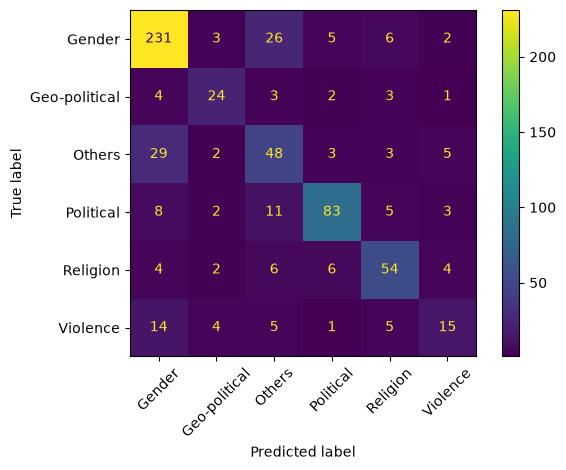

In [110]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

scores_char = char_wb_model.decision_function(X_dev)
scores_word = word_model.decision_function(X_dev)

# 85% Char-WB + 15% Word
ensemble_scores = (
    0.85 * scores_char +
    0.15 * scores_word
)

# Small decision-score bias found during development
classes = char_wb_model.classes_

ensemble_scores[:, list(classes).index("Others")] += 0.05
ensemble_scores[:, list(classes).index("Violence")] += 0.05

y_pred = classes[np.argmax(ensemble_scores, axis=1)]

accuracy = accuracy_score(y_dev, y_pred)
macro_f1 = f1_score(y_dev, y_pred, average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Macro-F1 : {macro_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_dev, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_dev, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_dev,
    y_pred,
    xticks_rotation=45
)

plt.tight_layout()
plt.show()

In [111]:
experiment_results = pd.DataFrame({
    "Experiment": [
        "Word TF-IDF + Linear SVM",
        "Character TF-IDF + Linear SVM",
        "Tuned Character TF-IDF",
        "Character + Linguistic Features",
        "Character-WB",
        "Character-WB + Others Weighting",
        "Character-WB + Word Ensemble",
        "Final Decision Bias"
    ],
    "Macro-F1": [
        0.5447,
        0.5756,
        0.6052,
        0.6195,
        0.6333,
        0.6442,
        0.6455,
        0.6460
    ]
})

experiment_results

,Experiment,Macro-F1
0,Word TF-IDF + Linear SVM,0.5447
1,Character TF-IDF + Linear SVM,0.5756
2,Tuned Character TF-IDF,0.6052
3,Character + Linguistic Features,0.6195
4,Character-WB,0.6333
5,Character-WB + Others Weighting,0.6442
6,Character-WB + Word Ensemble,0.6455
7,Final Decision Bias,0.6460
